# Data Loading

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import copy
import random
import time

BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Using device: {DEVICE}")

# 1. Data Loading
# 1. Data Loading (Standard Split)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download standard splits
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Standard MNIST Split: {len(train_data)} Training, {len(test_data)} Testing")

# Helper to access underlying data/targets for custom dataset creation
def extract_data_targets(dataset):
    # MNIST dataset object already holds data as a tensor (N, 28, 28)
    # We normalize it manually to match the transform: (pixel / 255 - 0.5) / 0.5
    data = dataset.data.float() / 255.0
    data = (data - 0.5) / 0.5

    # Add channel dimension: (N, 28, 28) -> (N, 1, 28, 28)
    data = data.unsqueeze(1)

    targets = dataset.targets
    return data, targets

# Extract tensors for our custom task datasets
train_X, train_Y = extract_data_targets(train_data)
test_X, test_Y = extract_data_targets(test_data)

print(f"Tensor Shapes - Train: {train_X.shape}, Test: {test_X.shape}")
print(f"Range: [{train_X.min()},{train_X.max()}]")

Using device: cuda
Standard MNIST Split: 60000 Training, 10000 Testing
Tensor Shapes - Train: torch.Size([60000, 1, 28, 28]), Test: torch.Size([10000, 1, 28, 28])
Range: [-1.0,1.0]


# Feature Extraction with PCA
Here we implement PCA to reduce dimensionality while retaining >90% variance. This serves as our baseline for reconstruction quality (Task 1 comparative analysis).


PCA Analysis: 87 components required to retain 90% variance (Original: 784).
PCA Reconstruction Baseline:


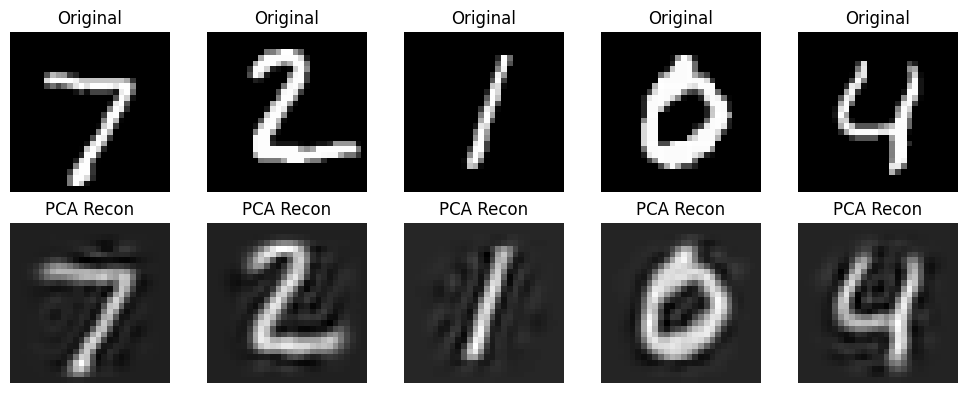

In [7]:
# Flatten data for PCA
X_flat = train_X.view(train_X.size(0), -1).numpy()
X_test_flat = test_X.view(test_X.size(0), -1).numpy()

# Fit PCA
pca = PCA(n_components=0.90) # Retain 90% variance
X_pca_train = pca.fit_transform(X_flat)
n_components = pca.n_components_

print(f"PCA Analysis: {n_components} components required to retain 90% variance (Original: 784).")

# Reconstruction for Comparison
X_test_pca_transformed = pca.transform(X_test_flat)
X_test_pca_reconstructed = pca.inverse_transform(X_test_pca_transformed)

# Visualization Function
def show_pca_results(original, reconstructed, num=5):
    plt.figure(figsize=(10, 4))
    for i in range(num):
        # Original
        ax = plt.subplot(2, num, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstructed
        ax = plt.subplot(2, num, i + 1 + num)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("PCA Recon")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("PCA Reconstruction Baseline:")
show_pca_results(X_test_flat, X_test_pca_reconstructed)

#Dataset Construction for Generative Tasks
We need specific datasets for the three tasks:

In [55]:
class ReconstructionDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        # Input is Image, Target is also Image
        img = self.images[idx]
        return img, img, self.labels[idx] # Return image, target image, and original label

class NextDigitDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
        # Pre-compute indices for each digit to quickly find target images
        self.digit_indices = {i: torch.where(labels == i)[0] for i in range(10)}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx].item()

        # Calculate next digit (9 -> 0)
        next_label = (label + 1) % 10

        # Randomly sample an image of the next digit from the dataset
        # This acts as the Ground Truth for the generative task
        target_idx = np.random.choice(self.digit_indices[next_label])
        target_img = self.images[target_idx]

        return img, target_img, torch.tensor(label), next_label # Added original 'label' here

class VisualAdderDataset(Dataset):
    def __init__(self, images, labels, length=None):
        self.images = images
        self.labels = labels
        self.length = length if length is not None else len(images)
        # Pre-compute indices for each digit to quickly find target images
        self.digit_indices = {i: torch.where(labels == i)[0] for i in range(10)}

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # 1. Uniformly sample a target SUM (0 to 18)
        target_sum = np.random.randint(0, 19)

        # 2. Find valid pairs (n1, n2) that add up to target_sum
        # Constraint: n1 and n2 must be single digits (0-9)
        min_n1 = max(0, target_sum - 9)
        max_n1 = min(9, target_sum)

        n1 = np.random.randint(min_n1, max_n1 + 1)
        n2 = target_sum - n1

        # 3. Decompose sum for targets
        tens = target_sum // 10
        units = target_sum % 10

        # 4. Fetch Images
        img1 = self.images[np.random.choice(self.digit_indices[n1])]
        img2 = self.images[np.random.choice(self.digit_indices[n2])]
        target_tens = self.images[np.random.choice(self.digit_indices[tens])]
        target_units = self.images[np.random.choice(self.digit_indices[units])]

        return img1, img2, target_tens, target_units, tens, units, n1, n2 # Return 8 items: inputs, target images, target labels, and input labels

# Instantiate Datasets
train_recon_ds = ReconstructionDataset(train_X, train_Y)
test_recon_ds = ReconstructionDataset(test_X, test_Y)

train_next_ds = NextDigitDataset(train_X, train_Y)
test_next_ds = NextDigitDataset(test_X, test_Y)

train_adder_ds = VisualAdderDataset(train_X, train_Y)
test_adder_ds = VisualAdderDataset(test_X, test_Y)

loaders = {
    'recon_train': DataLoader(train_recon_ds, batch_size=BATCH_SIZE, shuffle=True),
    'recon_test': DataLoader(test_recon_ds, batch_size=BATCH_SIZE, shuffle=False),
    'next_train': DataLoader(train_next_ds, batch_size=BATCH_SIZE, shuffle=True),
    'next_test': DataLoader(test_next_ds, batch_size=BATCH_SIZE, shuffle=False),
    'adder_train': DataLoader(train_adder_ds, batch_size=BATCH_SIZE, shuffle=True),
    'adder_test': DataLoader(test_adder_ds, batch_size=BATCH_SIZE, shuffle=False)
}

# Model Architectures
Validation Classifier
First, we build a standard CNN to which will verify if the generated digits are recognizable.

In [10]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

# Train the Validation Classifier
print("Training Validation Classifier (The Judge)...")
judge = Classifier().to(DEVICE)
optimizer_j = optim.Adam(judge.parameters(), lr=0.001)
criterion_j = nn.CrossEntropyLoss()

for epoch in range(10): # Quick training
    judge.train()
    for imgs, labels in DataLoader(train_data, batch_size=64, shuffle=True):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_j.zero_grad()
        loss = criterion_j(judge(imgs), labels)
        loss.backward()
        optimizer_j.step()
    print(f"Classifier Epoch {epoch+1} Complete")
judge.eval()
print("Classifier Ready.\n")

Training Validation Classifier (The Judge)...
Classifier Epoch 1 Complete
Classifier Epoch 2 Complete
Classifier Epoch 3 Complete
Classifier Epoch 4 Complete
Classifier Epoch 5 Complete
Classifier Epoch 6 Complete
Classifier Epoch 7 Complete
Classifier Epoch 8 Complete
Classifier Epoch 9 Complete
Classifier Epoch 10 Complete
Classifier Ready.



# Generative Models (Encoder-Decoder)
We implement a Convolutional Autoencoder-style Generator.

Task 1 (Reconstruct Digit) : Encoder(Img) $\to$ Latent $\to$ Decoder(Latent) $\to$ Target Img.

Task 2 (Next Digit): Encoder(Img) $\to$ Latent $\to$ Decoder(Latent) $\to$ Target Img.

Task 3 (Visual Adder): Encoder(Img1), Encoder(Img2) $\to$ Concat Latents $\to$ Decoder $\to$ 2 Output Channels (Tens, Units).

In [11]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*7*7, latent_dim),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, out_channels=1):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 32*7*7),
            nn.ReLU()
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, out_channels, 3, stride=2, padding=1, output_padding=1), # 28x28
            nn.Tanh() # Inputs are -1 to 1
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 32, 7, 7)
        return self.net(x)

#Used for both digit reconstruction and next digit generation
class NextDigitGenerator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim, out_channels=1)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class VisualAdder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # Shared Encoder
        self.encoder = Encoder(latent_dim)

        # Fusion Layer: Learn the Arithmetic Logic here
        # Takes 2 latents -> Processes -> Outputs a "Context" vector
        self.fusion = nn.Sequential(
            nn.Linear(latent_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, latent_dim * 2), # Expand back for the two decoders
            nn.ReLU()
        )

        # Separate Decoders (Disentanglement)
        self.decoder_tens = Decoder(latent_dim * 2, out_channels=1)
        self.decoder_units = Decoder(latent_dim * 2, out_channels=1)

    def forward(self, img1, img2):
        z1 = self.encoder(img1)
        z2 = self.encoder(img2)

        # Concatenate and Fuse
        z_cat = torch.cat([z1, z2], dim=1)
        z_fused = self.fusion(z_cat)

        # Decode separately
        out_tens = self.decoder_tens(z_fused)
        out_units = self.decoder_units(z_fused)

        return out_tens, out_units

# Training & Evaluation Logic

In [63]:
def train_model(model, task_type, train_loader, test_loader=None, judge_model=None, epochs=5, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Ensure Judge is frozen (we don't want to train it)
    if judge_model:
        judge_model.eval()

    # Store full history
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': [], 'total_time': 0}

    start_time = time.time()

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in train_loader:
            optimizer.zero_grad()

            # 1. Unpack Batch & Labels
            if task_type in ['next_digit', 'recon']:
                if task_type == 'recon':
                    inp, target, original_input_label = batch
                    next_label_for_acc = original_input_label
                elif task_type == 'next_digit':
                    inp, target, original_input_label, next_label_for_acc = batch

                inp, target, next_label_for_acc = inp.to(DEVICE), target.to(DEVICE), next_label_for_acc.to(DEVICE)

                output = model(inp)
                loss = criterion(output, target)

                # Accuracy Check (Train)
                if judge_model:
                    with torch.no_grad(): # Don't track gradients for accuracy check
                        preds = torch.argmax(judge_model(output), dim=1)
                        train_correct += (preds == next_label_for_acc).sum().item()
                        train_total += next_label_for_acc.size(0)

            elif task_type == 'adder':
                img1, img2, t_tens, t_units, l_tens, l_units, _, _ = batch
                img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
                t_tens, t_units = t_tens.to(DEVICE), t_units.to(DEVICE)
                l_tens, l_units = l_tens.to(DEVICE), l_units.to(DEVICE)

                out_tens, out_units = model(img1, img2)
                loss = criterion(out_tens, t_tens) + criterion(out_units, t_units)

                # Accuracy Check (Train)
                if judge_model:
                    with torch.no_grad():
                        p_tens = torch.argmax(judge_model(out_tens), dim=1)
                        p_units = torch.argmax(judge_model(out_units), dim=1)
                        train_correct += ((p_tens == l_tens) & (p_units == l_units)).sum().item()
                        train_total += l_tens.size(0)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Calculate Train Acc
        train_acc_msg = ""
        if judge_model and train_total > 0:
            avg_train_acc = train_correct / train_total
            history['train_acc'].append(avg_train_acc)
            train_acc_msg = f" | Train Acc: {avg_train_acc*100:.2f}%"

        # --- VALIDATION PHASE ---
        val_msg = ""
        if test_loader:
            model.eval()
            test_loss = 0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for batch in test_loader:
                    if task_type in ['next_digit', 'recon']:
                        if task_type == 'recon':
                            inp, target, original_input_label = batch
                            next_label_for_acc = original_input_label
                        elif task_type == 'next_digit':
                            inp, target, original_input_label, next_label_for_acc = batch

                        inp, target, next_label_for_acc = inp.to(DEVICE), target.to(DEVICE), next_label_for_acc.to(DEVICE)
                        gen = model(inp)
                        loss = criterion(gen, target)

                        if judge_model:
                            preds = torch.argmax(judge_model(gen), dim=1)
                            test_correct += (preds == next_label_for_acc).sum().item()
                            test_total += next_label_for_acc.size(0)

                    elif task_type == 'adder':
                        img1, img2, t_tens, t_units, l_tens, l_units, _, _ = batch
                        img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
                        t_tens, t_units = t_tens.to(DEVICE), t_units.to(DEVICE)
                        l_tens, l_units = l_tens.to(DEVICE), l_units.to(DEVICE)

                        out_tens, out_units = model(img1, img2)
                        loss = criterion(out_tens, t_tens) + criterion(out_units, t_units)

                        if judge_model:
                            p_tens = torch.argmax(judge_model(out_tens), dim=1)
                            p_units = torch.argmax(judge_model(out_units), dim=1)
                            test_correct += ((p_tens == l_tens) & (p_units == l_units)).sum().item()
                            test_total += l_tens.size(0)

                    test_loss += loss.item()

            avg_test_loss = test_loss / len(test_loader)
            history['test_loss'].append(avg_test_loss)

            test_acc_msg = ""
            if judge_model and test_total > 0:
                avg_test_acc = test_correct / test_total
                history['test_acc'].append(avg_test_acc)
                test_acc_msg = f" | Test Acc: {avg_test_acc*100:.2f}%"

            val_msg = f" | Test Loss: {avg_test_loss:.4f}{test_acc_msg}"

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}{train_acc_msg}{val_msg}")
    end_time = time.time()
    history['total_time'] = end_time - start_time
    print(f"Total Training Time: {history['total_time']:.2f} seconds")
    return history

def evaluate_model(model, task_type, test_loader, judge_model):
    model.eval()
    correct = 0
    total = 0

    inputs_log = []
    outputs_log = []

    with torch.no_grad():
        for batch in test_loader:
            if task_type == 'next_digit' or task_type == 'recon':
                if task_type == 'recon':
                    # ReconstructionDataset returns (img, img, original_label)
                    inp, target, original_input_label = batch
                    next_label_for_acc = original_input_label
                elif task_type == 'next_digit':
                    # NextDigitDataset now returns (img, target_img, original_input_label, next_label)
                    inp, target, original_input_label, next_label_for_acc = batch

                inp, target = inp.to(DEVICE), target.to(DEVICE)
                original_input_label, next_label_for_acc = original_input_label.to(DEVICE), next_label_for_acc.to(DEVICE)

                gen_img = model(inp)

                # Validation: Does the judge recognize the generated image correctly?
                judge_preds = torch.argmax(judge_model(gen_img), dim=1)
                correct += (judge_preds == next_label_for_acc).sum().item()
                total += next_label_for_acc.size(0)

                if len(inputs_log) < 5:
                    if task_type == 'next_digit':
                        inputs_log.append((inp.cpu(), original_input_label.cpu()))
                        outputs_log.append((gen_img.cpu(), next_label_for_acc.cpu()))
                    else:
                        inputs_log.append(inp.cpu())
                        outputs_log.append(gen_img.cpu())

            elif task_type == 'adder':
                # VisualAdderDataset returns (img1, img2, target_tens_img, target_units_img, tens_label, units_label, n1, n2)
                # We need img1, img2 for input, and lbl_tens, lbl_units for comparison with judge predictions.
                img1, img2, _, _, lbl_tens, lbl_units, lbl_n1, lbl_n2 = batch # Unpack 8 values, _ discards target images
                img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
                lbl_tens, lbl_units = lbl_tens.to(DEVICE), lbl_units.to(DEVICE)
                lbl_n1, lbl_n2 = lbl_n1.to(DEVICE), lbl_n2.to(DEVICE)

                out_tens, out_units = model(img1, img2)

                pred_tens = torch.argmax(judge_model(out_tens), dim=1)
                pred_units = torch.argmax(judge_model(out_units), dim=1)

                correct += ((pred_tens == lbl_tens) & (pred_units == lbl_units)).sum().item()
                total += lbl_tens.size(0)

                if len(inputs_log) < 5:
                    inputs_log.append((img1.cpu(), img2.cpu(), lbl_n1.cpu(), lbl_n2.cpu()))
                    outputs_log.append((out_tens.cpu(), out_units.cpu()))
            else:
                raise ValueError(f"Unknown task type for evaluation: {task_type}")

    acc = correct / total
    return acc, inputs_log, outputs_log

In [13]:
def plot_loss_curve(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['train_loss'], 'b-o', linewidth=2, label='Training Loss')

    if len(history['test_loss']) > 0:
        plt.plot(epochs, history['test_loss'], 'r-s', linewidth=2, label='Test Loss')

    plt.title('Model Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

def plot_accuracy_curve(history):
    # Check if we have accuracy data
    if len(history['test_acc']) == 0 and len(history['train_acc']) == 0:
        print("No accuracy data available to plot.")
        return

    epochs = range(1, len(history['test_acc']) + 1)

    plt.figure(figsize=(10, 5))

    # Plot Train Accuracy
    if len(history['train_acc']) > 0:
        plt.plot(epochs, history['train_acc'], 'b-o', linewidth=2, label='Train Accuracy (Judge)')

    # Plot Test Accuracy
    plt.plot(epochs, history['test_acc'], 'g-^', linewidth=2, label='Test Accuracy (Judge)')

    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (0.0 - 1.0)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Experiments & Results


##Task 1 : Digit Reconstruction

We train the model to compress the image into a latent code and then reconstruct the same image ($Input \approx Output$). We compare this with PCA reconstruction

In [14]:
print("--- Task 1:  Digit Reconstruction ---")
model_recon = NextDigitGenerator(latent_dim=64).to(DEVICE)
hist_recon = train_model(model_recon, 'recon', loaders['recon_train'], loaders['recon_test'], judge, epochs=25)
acc_recon, in_viz_recon, out_viz_recon = evaluate_model(model_recon, 'recon', loaders['recon_test'], judge)
print(f"Autoencoder Reconstruction Accuracy (Judge): {acc_recon*100:.2f}%")


--- Task 1:  Digit Reconstruction ---
Epoch 1/25 - Train Loss: 0.1132 | Train Acc: 77.44% | Test Loss: 0.0584 | Test Acc: 94.08%
Epoch 2/25 - Train Loss: 0.0541 | Train Acc: 94.52% | Test Loss: 0.0478 | Test Acc: 95.26%
Epoch 3/25 - Train Loss: 0.0467 | Train Acc: 95.64% | Test Loss: 0.0428 | Test Acc: 95.94%
Epoch 4/25 - Train Loss: 0.0425 | Train Acc: 96.25% | Test Loss: 0.0390 | Test Acc: 96.77%
Epoch 5/25 - Train Loss: 0.0387 | Train Acc: 96.92% | Test Loss: 0.0364 | Test Acc: 96.79%
Epoch 6/25 - Train Loss: 0.0367 | Train Acc: 97.18% | Test Loss: 0.0352 | Test Acc: 97.26%
Epoch 7/25 - Train Loss: 0.0354 | Train Acc: 97.34% | Test Loss: 0.0342 | Test Acc: 97.31%
Epoch 8/25 - Train Loss: 0.0344 | Train Acc: 97.45% | Test Loss: 0.0330 | Test Acc: 97.15%
Epoch 9/25 - Train Loss: 0.0336 | Train Acc: 97.54% | Test Loss: 0.0325 | Test Acc: 97.26%
Epoch 10/25 - Train Loss: 0.0329 | Train Acc: 97.63% | Test Loss: 0.0322 | Test Acc: 97.45%
Epoch 11/25 - Train Loss: 0.0324 | Train Acc: 97.70

In [33]:
def pca_vs_ae(model, real_imgs):
  # Neural Network Reconstruction
  with torch.no_grad():
    ae_recon = model_recon(real_imgs).cpu()

  # PCA Reconstruction
  # Flatten images to (N, 784) for PCA
  flat_imgs = real_imgs.view(real_imgs.size(0), -1).cpu().numpy()
  # Transform -> Inverse Transform
  pca_compressed = pca.transform(flat_imgs)
  pca_recon_flat = pca.inverse_transform(pca_compressed)
  # Reshape back to image (N, 1, 28, 28)
  pca_recon = pca_recon_flat.reshape(-1, 1, 28, 28)

  real_imgs = real_imgs.cpu()
  plt.figure(figsize=(12, 6))
  num_samples = real_imgs.size(0)
  # Plot Comparison
  for i in range(num_samples):
    # Original
    plt.subplot(3, num_samples, i + 1)
    plt.imshow(real_imgs[i].squeeze(), cmap='gray')
    if i == 0: plt.title("Original", fontweight='bold')
    plt.axis('off')

    # PCA
    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.imshow(pca_recon[i].squeeze(), cmap='gray')
    if i == 0: plt.title(f"PCA (Linear)\n{n_components} components", fontweight='bold')
    plt.axis('off')

    # Autoencoder
    plt.subplot(3, num_samples, i + 1 + (2 * num_samples))
    plt.imshow(ae_recon[i].squeeze(), cmap='gray')
    if i == 0: plt.title("Autoencoder", fontweight='bold')
    plt.axis('off')

  plt.tight_layout()
  plt.show()



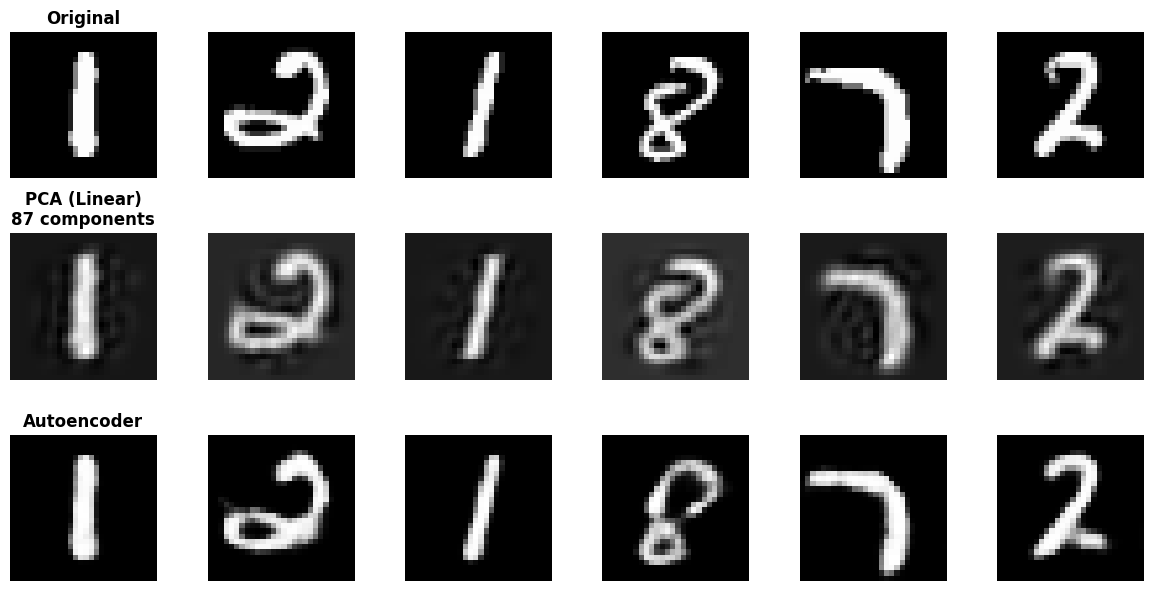

In [49]:
model_recon.eval()

# Get 6 random test images from the entire test_recon_ds
random_indices = random.sample(range(len(test_recon_ds)), 6)
real_imgs = torch.stack([test_recon_ds[i][0] for i in random_indices]).to(DEVICE)

pca_vs_ae(model_recon, real_imgs)

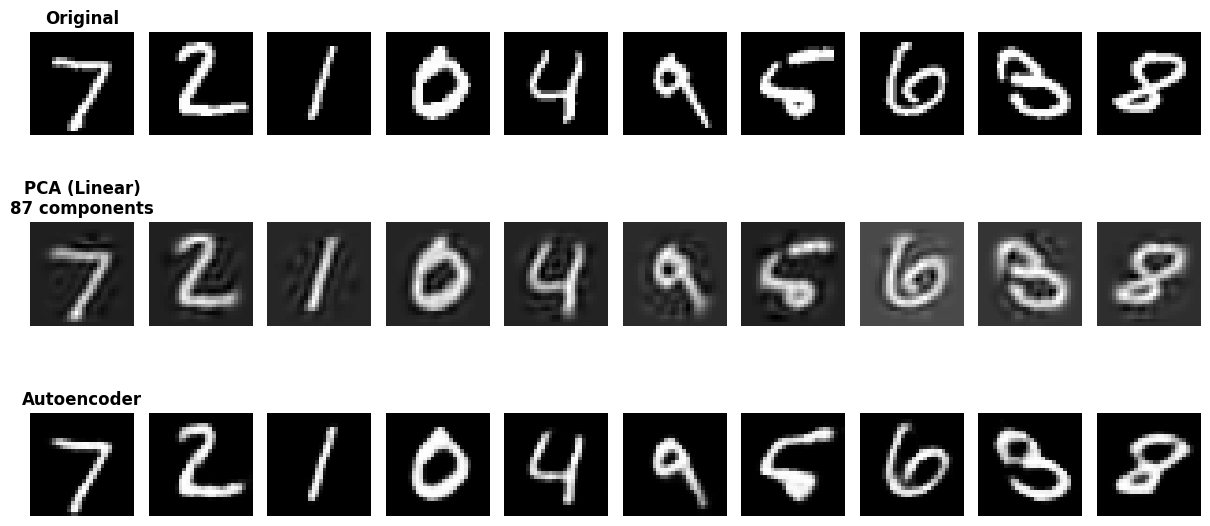

In [50]:
# Collect one image for each digit (0-9)
imgs_for_viz = []
labels_seen = set()

for i in range(len(test_recon_ds)):
    if len(labels_seen) == 10:
        break

    img, _, label = test_recon_ds[i]
    if label.item() not in labels_seen:
        imgs_for_viz.append(img)
        labels_seen.add(label.item())


real_imgs_per_digit = torch.stack(imgs_for_viz).to(DEVICE)
pca_vs_ae(model_recon, real_imgs_per_digit)

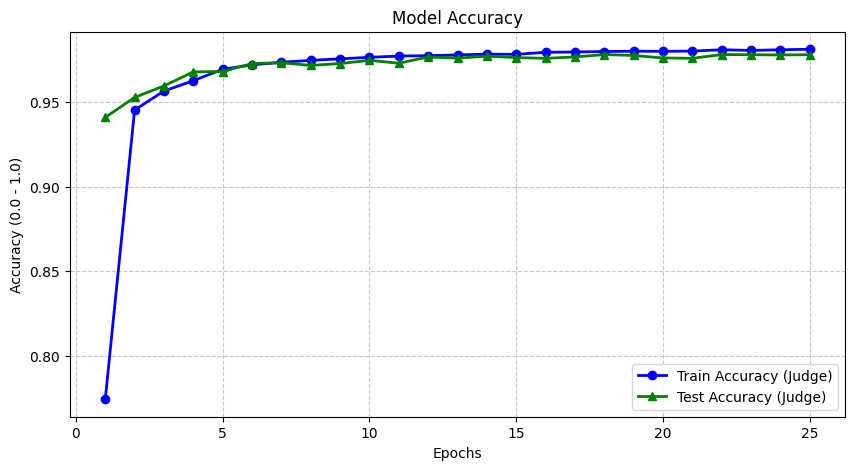

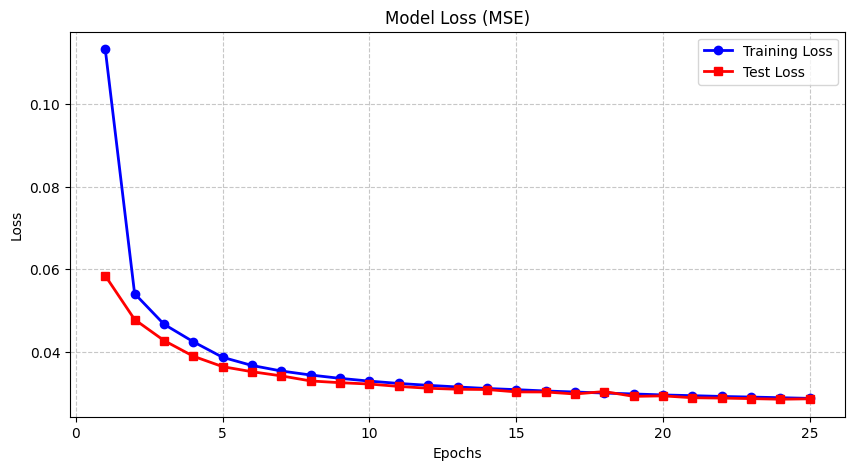

In [17]:
plot_accuracy_curve(hist_recon)
plot_loss_curve(hist_recon)

###Latent dim = 128

--- Task 1:  Digit Reconstruction ---
Epoch 1/25 - Train Loss: 0.0922 | Train Acc: 82.30% | Test Loss: 0.0367 | Test Acc: 96.67%
Epoch 2/25 - Train Loss: 0.0324 | Train Acc: 97.75% | Test Loss: 0.0284 | Test Acc: 97.83%
Epoch 3/25 - Train Loss: 0.0275 | Train Acc: 98.27% | Test Loss: 0.0254 | Test Acc: 98.14%
Epoch 4/25 - Train Loss: 0.0253 | Train Acc: 98.47% | Test Loss: 0.0235 | Test Acc: 98.18%
Epoch 5/25 - Train Loss: 0.0238 | Train Acc: 98.59% | Test Loss: 0.0227 | Test Acc: 98.16%
Epoch 6/25 - Train Loss: 0.0228 | Train Acc: 98.67% | Test Loss: 0.0220 | Test Acc: 98.36%
Epoch 7/25 - Train Loss: 0.0220 | Train Acc: 98.77% | Test Loss: 0.0211 | Test Acc: 98.28%
Epoch 8/25 - Train Loss: 0.0214 | Train Acc: 98.79% | Test Loss: 0.0205 | Test Acc: 98.34%
Epoch 9/25 - Train Loss: 0.0209 | Train Acc: 98.84% | Test Loss: 0.0200 | Test Acc: 98.41%
Epoch 10/25 - Train Loss: 0.0204 | Train Acc: 98.84% | Test Loss: 0.0199 | Test Acc: 98.49%
Epoch 11/25 - Train Loss: 0.0201 | Train Acc: 98.91

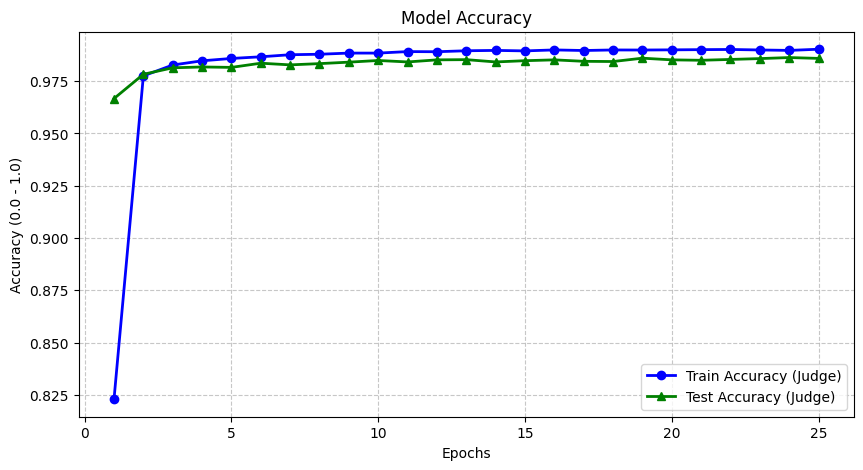

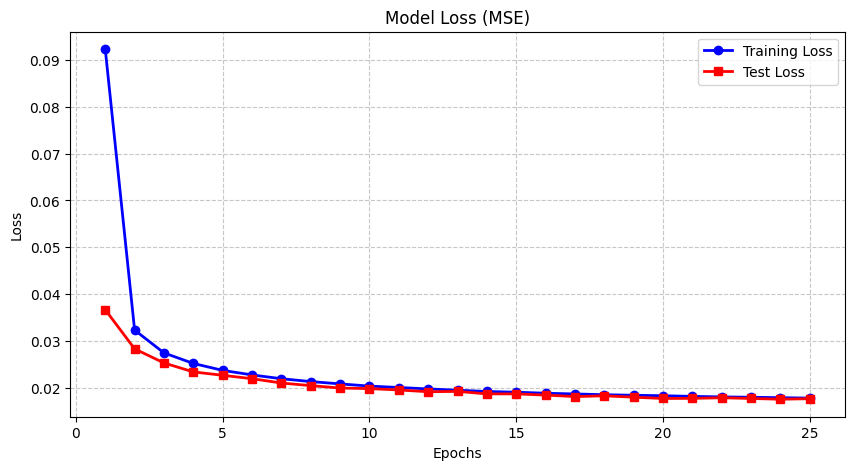

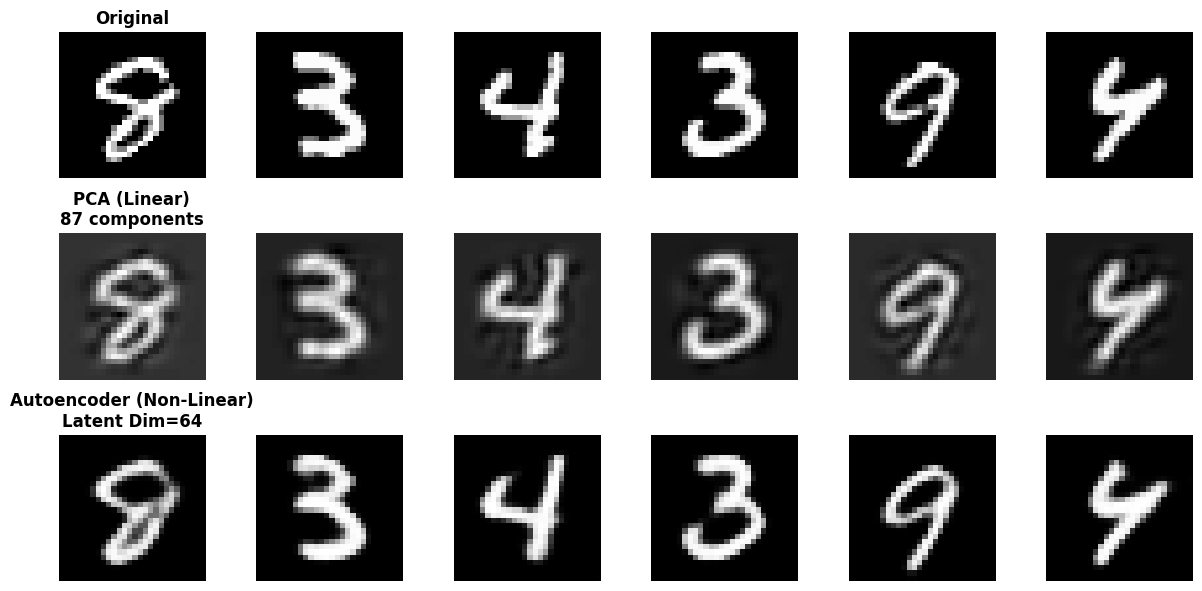

In [30]:
print("--- Task 1:  Digit Reconstruction ---")
model_recon128 = NextDigitGenerator(latent_dim=128).to(DEVICE)
hist_recon128 = train_model(model_recon128, 'recon', loaders['recon_train'], loaders['recon_test'], judge, epochs=25)
acc_recon128, in_viz_recon128, out_viz_recon128 = evaluate_model(model_recon128, 'recon', loaders['recon_test'], judge)
print(f"Autoencoder Reconstruction Accuracy (Judge): {acc_recon128*100:.2f}%")
plot_accuracy_curve(hist_recon128)
plot_loss_curve(hist_recon128)
pca_vs_ae(model_recon128, real_imgs)

###'Judge' evaluation on the PCA reconstructed images

'Judge' Accuracy on PCA Reconstructed Images: 98.49%


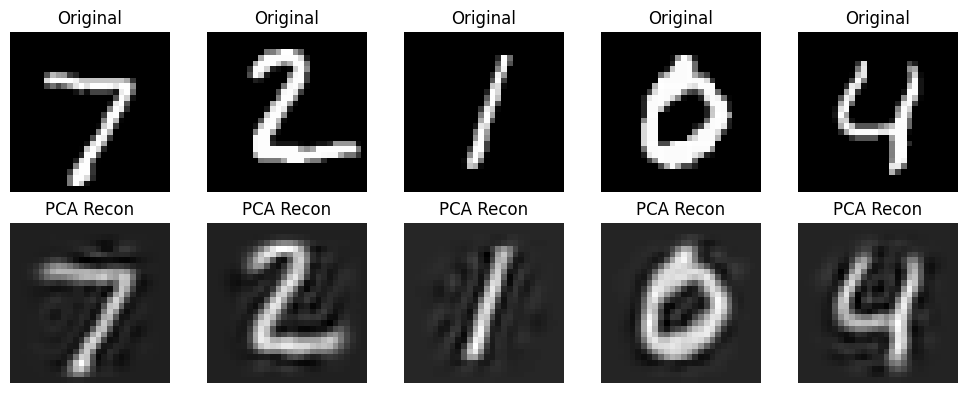

Average MSE Loss for PCA Reconstructed Images: 0.0262


In [32]:
#Flatten the test_X tensor
flat_test_X = test_X.view(test_X.size(0), -1).numpy()

# Transform the flattened test images using the pre-trained pca object
pca_transformed_test = pca.transform(flat_test_X)

# Reconstruct the images
pca_reconstructed_flat_test = pca.inverse_transform(pca_transformed_test)

# Reshape the reconstructed images back to their original dimensions
pca_reconstructed_test = pca_reconstructed_flat_test.reshape(-1, 1, 28, 28)

#Convert the reconstructed NumPy array back into a PyTorch tensor and move to DEVICE
pca_reconstructed_tensor = torch.from_numpy(pca_reconstructed_test).float().to(DEVICE)

judge.eval()

#Use the judge model to get predictions for the reconstructed images
with torch.no_grad():
    judge_preds_on_pca = torch.argmax(judge(pca_reconstructed_tensor), dim=1)

# Calculate the accuracy
# Ensure test_Y is also on the device for comparison if it's not already
current_test_Y = test_Y.to(DEVICE)
pca_recon_acc = (judge_preds_on_pca == current_test_Y).float().mean().item()

#Print the calculated pca_recon_acc
print(f"'Judge' Accuracy on PCA Reconstructed Images: {pca_recon_acc*100:.2f}%")

show_pca_results(flat_test_X, pca_reconstructed_test)


# Calculate MSE loss for PCA reconstructed images
# Convert original test_X to device for comparison
original_test_X_on_device = test_X.to(DEVICE)

criterion = nn.MSELoss()
with torch.no_grad():
    pca_mse_loss = criterion(pca_reconstructed_tensor, original_test_X_on_device).item()

print(f"Average MSE Loss for PCA Reconstructed Images: {pca_mse_loss:.4f}")


## Task 2: Next Digit Generation

We train the model to predict $n+1$. We will run a quick Hyperparameter check (Latent Dim 32 vs 64).

In [85]:
# Hyperparameter Loop
latent_dims = [32, 64, 128]
results = {}

print("--- Task 2: Next Digit Generation ---")

for ld in latent_dims:
    print(f"\nTraining with Latent Dim: {ld}")
    model_next = NextDigitGenerator(latent_dim=ld).to(DEVICE)
    hist = train_model(model_next, 'next_digit', loaders['next_train'], loaders['next_test'], judge, epochs=15)
    acc, _, _ = evaluate_model(model_next, 'next_digit', loaders['next_test'], judge)
    results[ld] = {'model': model_next, 'acc': acc, 'loss': hist['train_loss']}
    print(f"Latent {ld} -> Test Accuracy (Judge): {acc*100:.2f}%")

# Select best model for visualization
best_ld = max(results, key=lambda x: results[x]['acc'])
print(f"\nBest Model: Latent Dim {best_ld}")
best_model_next = results[best_ld]['model']
_, in_viz, out_viz = evaluate_model(best_model_next, 'next_digit', loaders['next_test'], judge)



--- Task 2: Next Digit Generation ---

Training with Latent Dim: 32
Epoch 1/15 - Train Loss: 0.2821 | Train Acc: 42.70% | Test Loss: 0.2319 | Test Acc: 78.70%
Epoch 2/15 - Train Loss: 0.2274 | Train Acc: 86.64% | Test Loss: 0.2238 | Test Acc: 92.27%
Epoch 3/15 - Train Loss: 0.2226 | Train Acc: 93.38% | Test Loss: 0.2208 | Test Acc: 95.80%
Epoch 4/15 - Train Loss: 0.2210 | Train Acc: 95.36% | Test Loss: 0.2201 | Test Acc: 96.57%
Epoch 5/15 - Train Loss: 0.2199 | Train Acc: 96.38% | Test Loss: 0.2193 | Test Acc: 97.05%
Epoch 6/15 - Train Loss: 0.2191 | Train Acc: 96.96% | Test Loss: 0.2173 | Test Acc: 97.13%
Epoch 7/15 - Train Loss: 0.2195 | Train Acc: 97.33% | Test Loss: 0.2186 | Test Acc: 97.58%
Epoch 8/15 - Train Loss: 0.2184 | Train Acc: 97.60% | Test Loss: 0.2182 | Test Acc: 96.90%
Epoch 9/15 - Train Loss: 0.2183 | Train Acc: 97.89% | Test Loss: 0.2183 | Test Acc: 97.63%
Epoch 10/15 - Train Loss: 0.2187 | Train Acc: 98.06% | Test Loss: 0.2184 | Test Acc: 97.97%
Epoch 11/15 - Train L

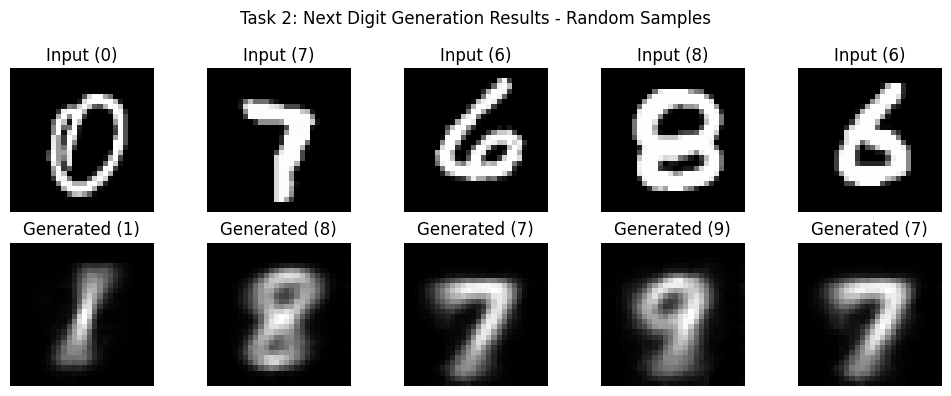

In [83]:
def plot_next_digit(model, dataset, num_samples=5):
    model.eval()
    plt.figure(figsize=(10, 4))

    random_indices = random.sample(range(len(dataset)), num_samples)

    input_images_list = []
    original_labels_list = []
    next_labels_list = []

    for idx in random_indices:
        inp_img, _, original_label, next_label = dataset[idx]
        input_images_list.append(inp_img)
        original_labels_list.append(original_label)
        next_labels_list.append(next_label)

    # Stack and move to device for model inference
    input_imgs_tensor = torch.stack(input_images_list).to(DEVICE)

    with torch.no_grad():
        generated_imgs_tensor = model(input_imgs_tensor)

    # Move back to CPU for plotting
    input_imgs_cpu = input_imgs_tensor.cpu()
    generated_imgs_cpu = generated_imgs_tensor.cpu()

    for i in range(num_samples):
        # Original Input Image
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(input_imgs_cpu[i].squeeze(), cmap='gray')
        plt.title(f"Input ({original_labels_list[i].item()})")
        plt.axis('off')

        # Generated Next Digit Image
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(generated_imgs_cpu[i].squeeze(), cmap='gray')
        plt.title(f"Generated ({next_labels_list[i]})")
        plt.axis('off')

    plt.suptitle("Task 2: Next Digit Generation Results - Random Samples")
    plt.tight_layout()
    plt.show()

# Now call the modified function with the best model and test dataset
plot_next_digit(best_model_next, test_next_ds)

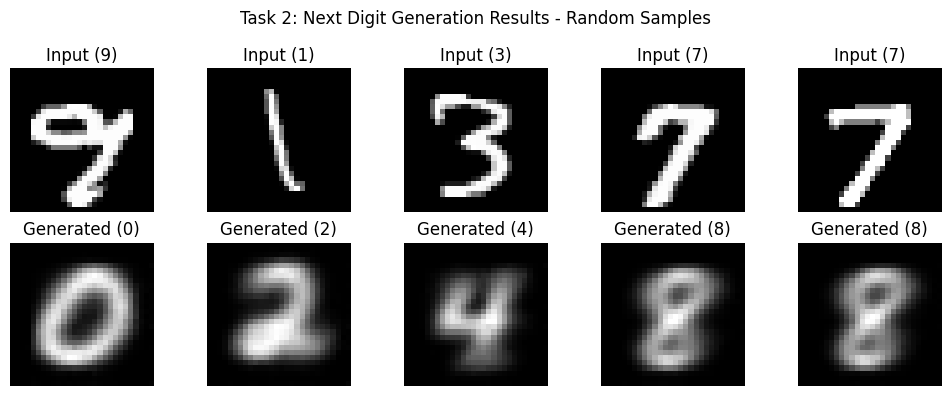

In [89]:
plot_next_digit(best_model_next, test_next_ds)

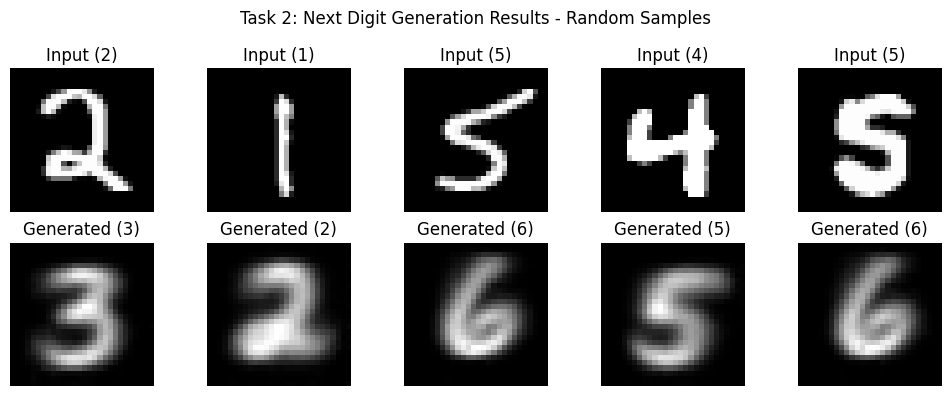

In [94]:
plot_next_digit(best_model_next, test_next_ds)

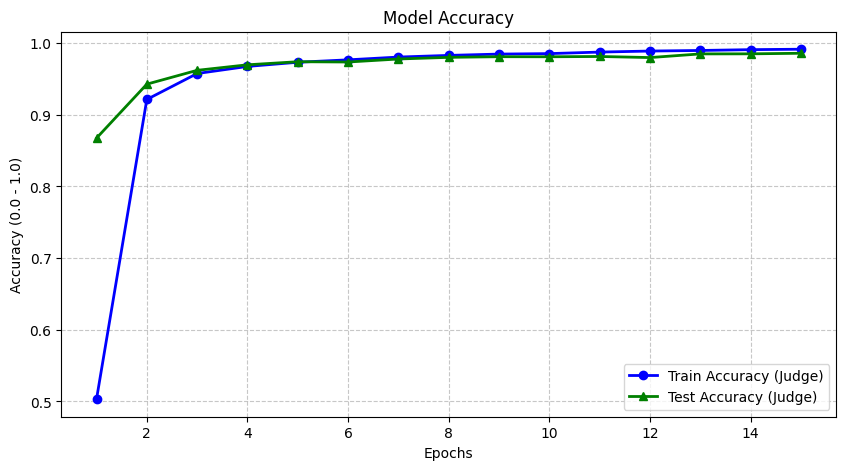

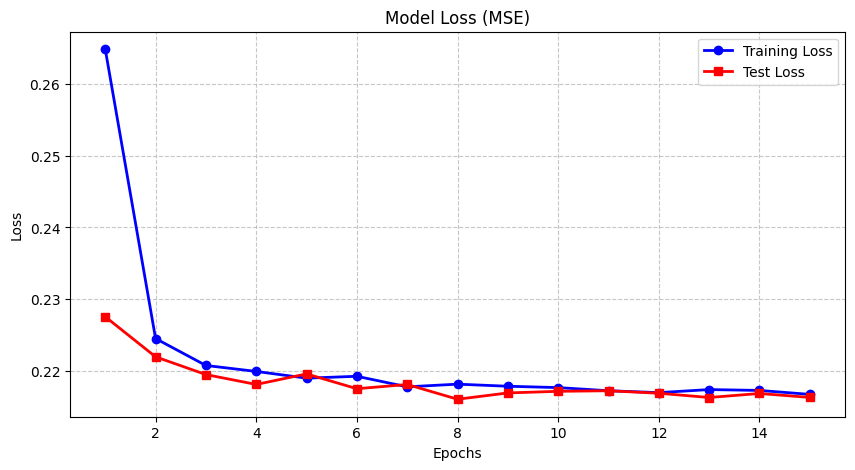

In [86]:
plot_accuracy_curve(hist)
plot_loss_curve(hist)

##Task 3: Visual Adder
We train the network to sum two images.


--- Task 3: Visual Adder ---
Epoch 1/25 - Train Loss: 0.4890 | Train Acc: 17.72% | Test Loss: 0.4560 | Test Acc: 28.16%
Epoch 2/25 - Train Loss: 0.4412 | Train Acc: 57.43% | Test Loss: 0.4238 | Test Acc: 78.42%
Epoch 3/25 - Train Loss: 0.4249 | Train Acc: 82.70% | Test Loss: 0.4153 | Test Acc: 88.50%
Epoch 4/25 - Train Loss: 0.4192 | Train Acc: 88.59% | Test Loss: 0.4159 | Test Acc: 90.56%
Epoch 5/25 - Train Loss: 0.4168 | Train Acc: 91.18% | Test Loss: 0.4160 | Test Acc: 91.44%
Epoch 6/25 - Train Loss: 0.4152 | Train Acc: 92.61% | Test Loss: 0.4097 | Test Acc: 92.69%
Epoch 7/25 - Train Loss: 0.4137 | Train Acc: 93.43% | Test Loss: 0.4096 | Test Acc: 93.79%
Epoch 8/25 - Train Loss: 0.4127 | Train Acc: 94.08% | Test Loss: 0.4102 | Test Acc: 93.45%
Epoch 9/25 - Train Loss: 0.4122 | Train Acc: 94.68% | Test Loss: 0.4108 | Test Acc: 94.72%
Epoch 10/25 - Train Loss: 0.4112 | Train Acc: 95.41% | Test Loss: 0.4096 | Test Acc: 94.99%
Epoch 11/25 - Train Loss: 0.4112 | Train Acc: 95.43% | Test

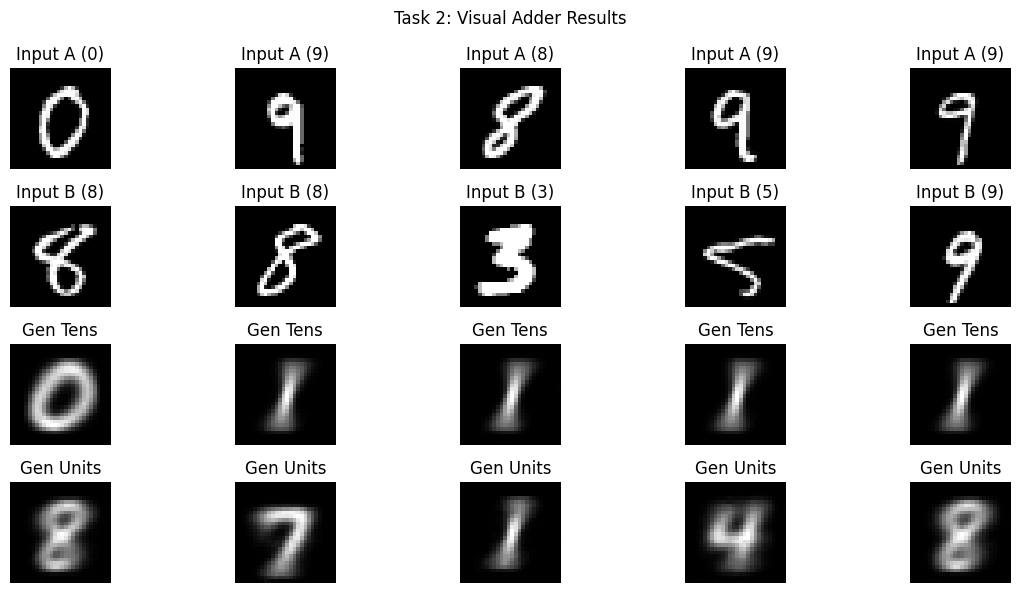

In [96]:
print("\n--- Task 3: Visual Adder ---")
adder_model = VisualAdder(latent_dim=64).to(DEVICE)
hist_adder = train_model(adder_model, 'adder', loaders['adder_train'], loaders['adder_test'], judge, epochs=25)

acc_adder, in_viz_add, out_viz_add = evaluate_model(adder_model, 'adder', loaders['adder_test'], judge)
print(f"Visual Adder Accuracy (Judge): {acc_adder*100:.2f}%")



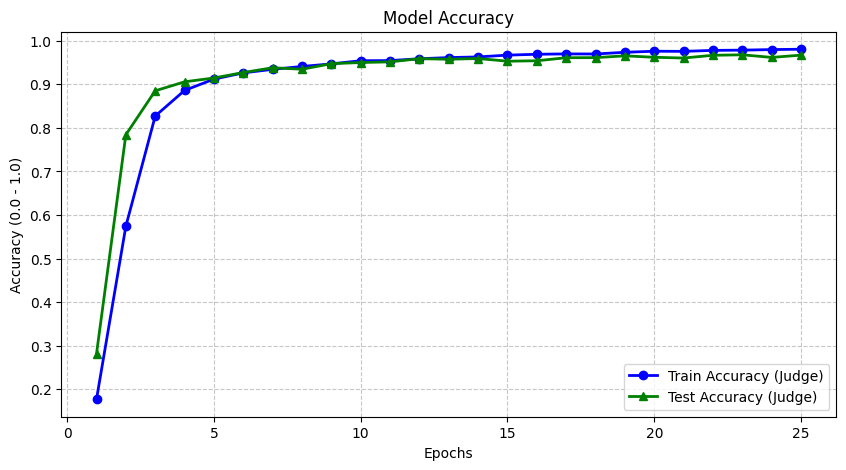

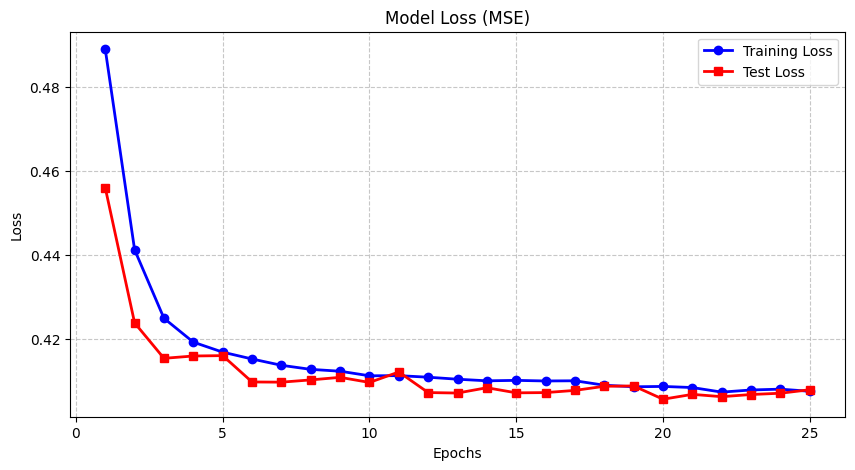

In [97]:
plot_accuracy_curve(hist_adder)
plot_loss_curve(hist_adder)

In [98]:
#  Quantitative Evaluation
adder_model.eval()
correct_all = 0
total = 0

print("\nEvaluating on Test Set...")
with torch.no_grad():
    for batch in loaders['adder_test']:
        img1, img2, _, _, lbl_tens, lbl_units, _, _ = batch
        img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
        lbl_tens, lbl_units = lbl_tens.to(DEVICE), lbl_units.to(DEVICE)

        g_t, g_u = adder_model(img1, img2)

        p_t = torch.argmax(judge(g_t), 1)
        p_u = torch.argmax(judge(g_u), 1)

        correct_all += ((p_t == lbl_tens) & (p_u == lbl_units)).sum().item()
        total += lbl_tens.size(0)

print(f"Final Visual Adder Accuracy: {correct_all/total*100:.2f}%")


Evaluating on Test Set...
Final Visual Adder Accuracy: 96.60%


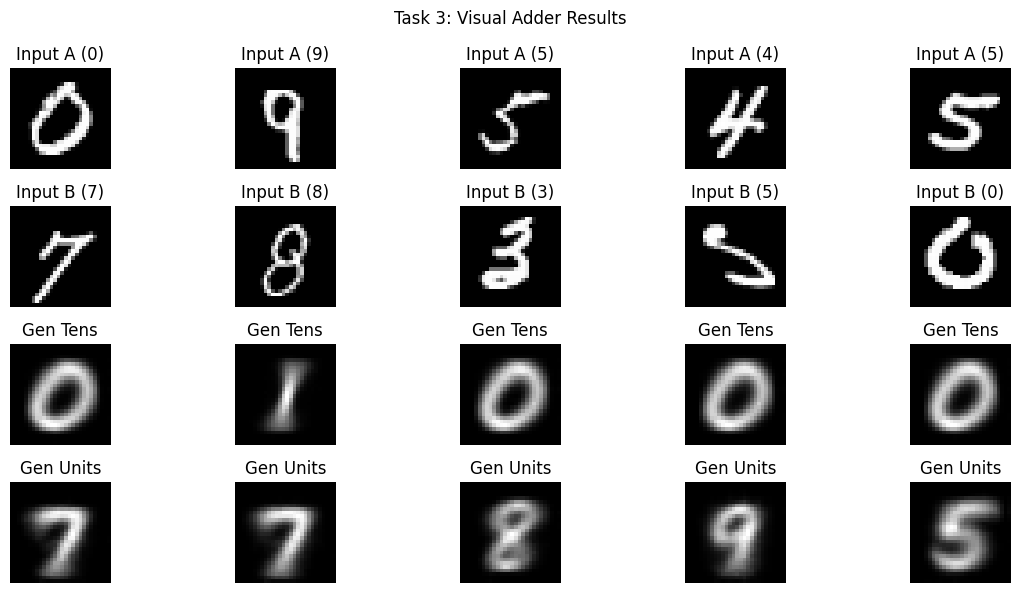

In [100]:
# Visual Evaluation
def plot_adder(inputs, outputs):
    in1, in2, n1_labels, n2_labels = inputs[0] # Unpack n1 and n2 labels
    out_t, out_u = outputs[0]

    plt.figure(figsize=(12, 6))
    for i in range(5):
        # Inputs
        plt.subplot(4, 5, i+1)
        plt.imshow(in1[i].squeeze(), cmap='gray')
        plt.title(f"Input A ({n1_labels[i].item()})") # Display true label
        plt.axis('off')

        plt.subplot(4, 5, i+6)
        plt.imshow(in2[i].squeeze(), cmap='gray')
        plt.title(f"Input B ({n2_labels[i].item()})") # Display true label
        plt.axis('off')

        # Outputs
        plt.subplot(4, 5, i+11)
        plt.imshow(out_t[i].squeeze(), cmap='gray')
        plt.title("Gen Tens")
        plt.axis('off')

        plt.subplot(4, 5, i+16)
        plt.imshow(out_u[i].squeeze(), cmap='gray')
        plt.title("Gen Units")
        plt.axis('off')
    plt.suptitle("Task 3: Visual Adder Results")
    plt.tight_layout()
    plt.show()

plot_adder(in_viz_add, out_viz_add)

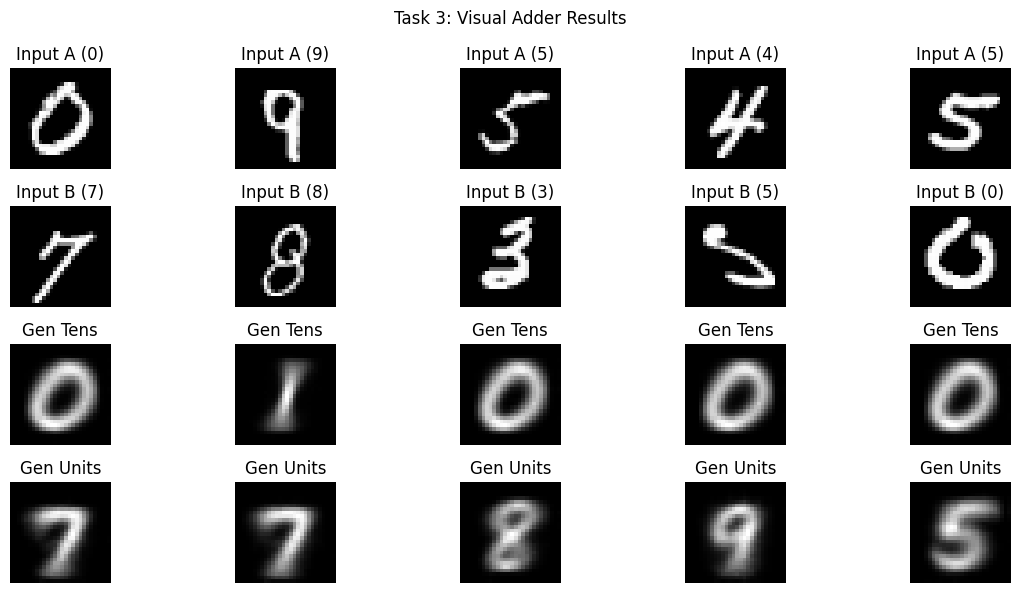

In [102]:
plot_adder(in_viz_add, out_viz_add)


--- All Addition Cases ---
Case: 0 + 0


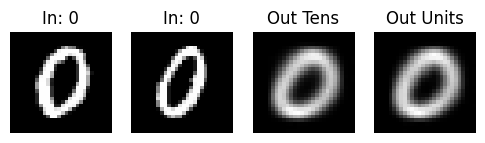

Case: 0 + 1


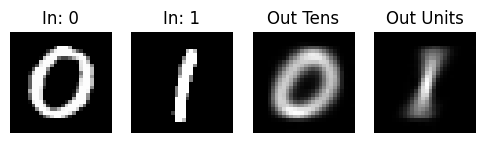

Case: 0 + 2


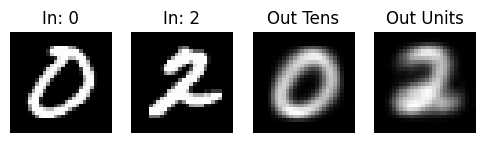

Case: 0 + 3


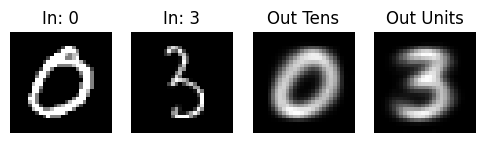

Case: 0 + 4


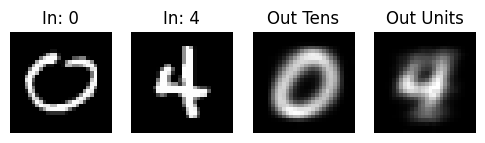

Case: 0 + 5


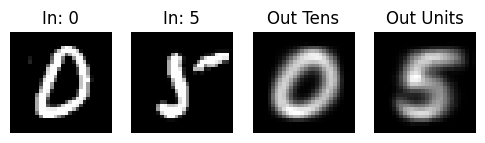

Case: 0 + 6


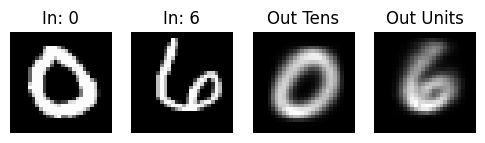

Case: 0 + 7


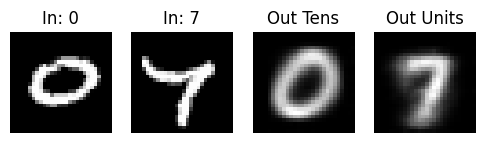

Case: 0 + 8


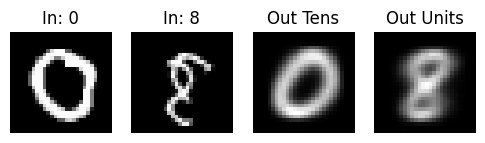

Case: 0 + 9


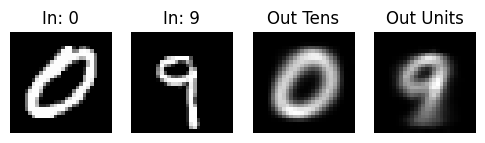

Case: 1 + 0


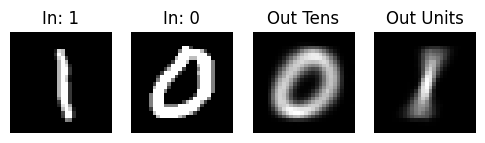

Case: 1 + 1


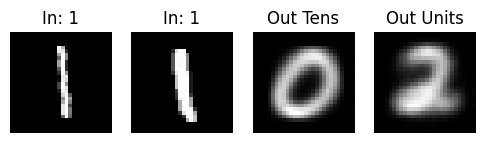

Case: 1 + 2


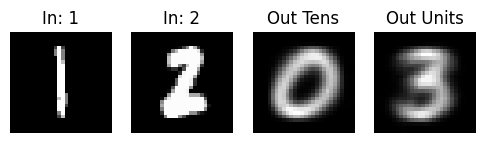

Case: 1 + 3


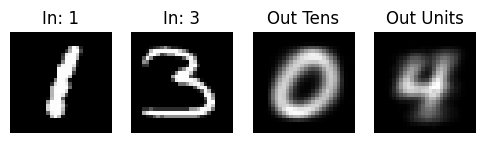

Case: 1 + 4


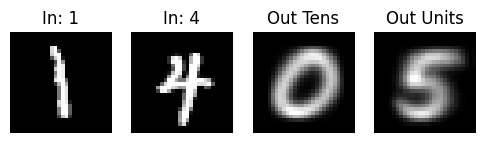

Case: 1 + 5


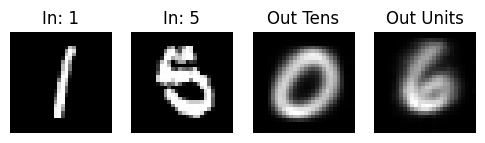

Case: 1 + 6


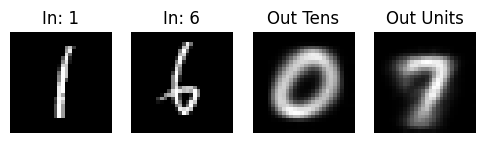

Case: 1 + 7


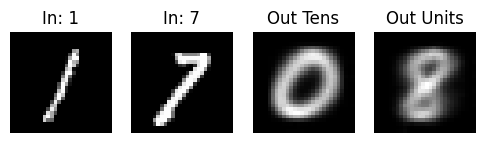

Case: 1 + 8


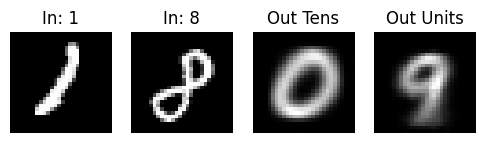

Case: 1 + 9


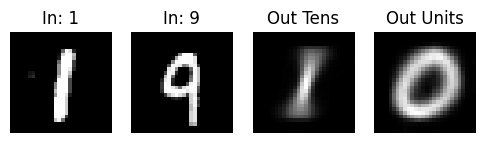

Case: 2 + 0


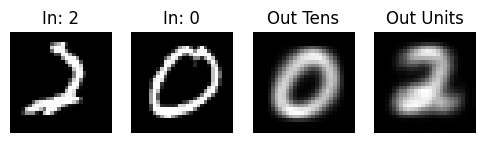

Case: 2 + 1


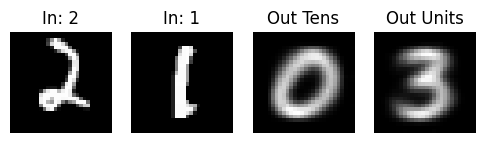

Case: 2 + 2


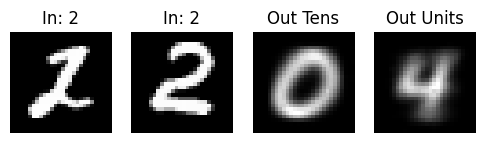

Case: 2 + 3


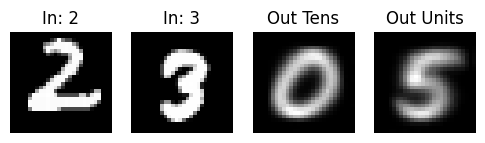

Case: 2 + 4


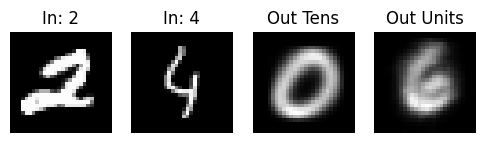

Case: 2 + 5


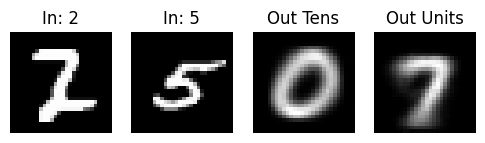

Case: 2 + 6


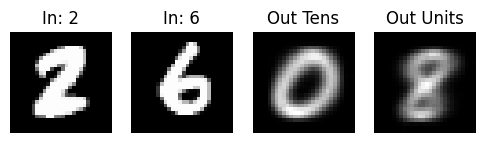

Case: 2 + 7


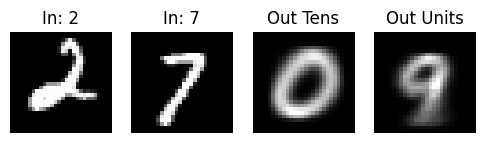

Case: 2 + 8


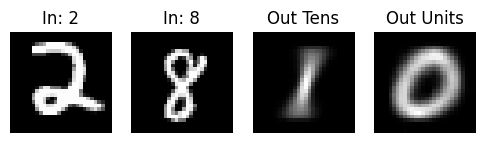

Case: 2 + 9


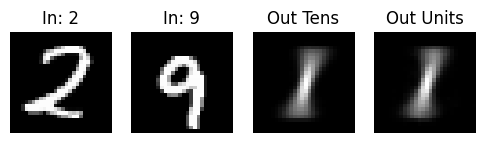

Case: 3 + 0


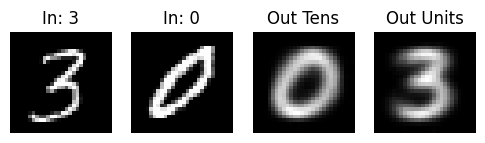

Case: 3 + 1


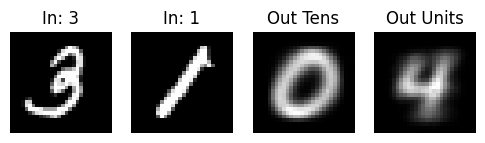

Case: 3 + 2


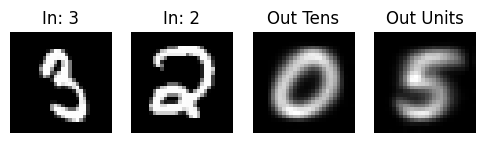

Case: 3 + 3


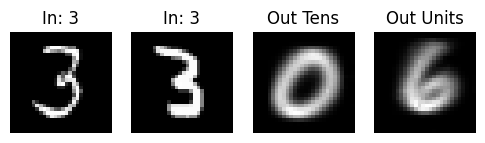

Case: 3 + 4


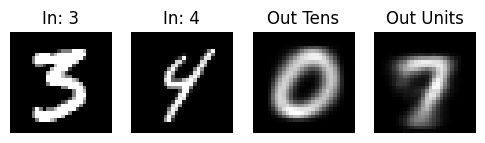

Case: 3 + 5


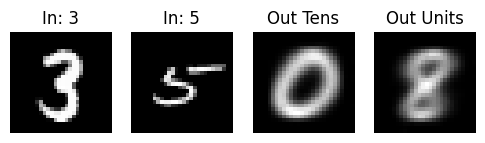

Case: 3 + 6


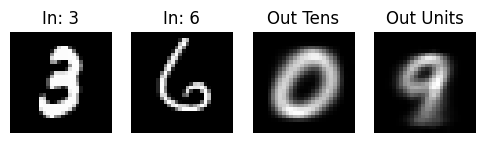

Case: 3 + 7


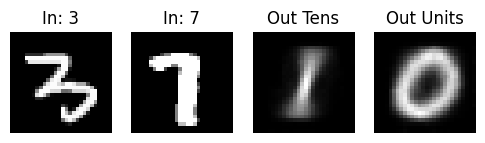

Case: 3 + 8


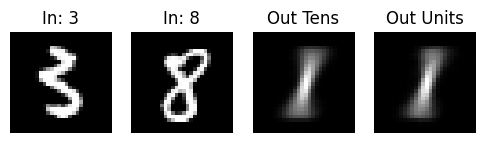

Case: 3 + 9


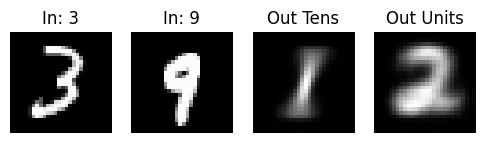

Case: 4 + 0


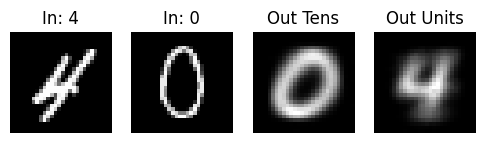

Case: 4 + 1


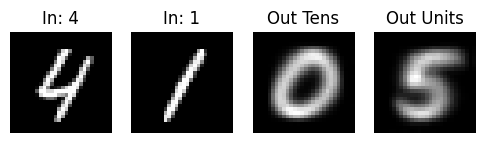

Case: 4 + 2


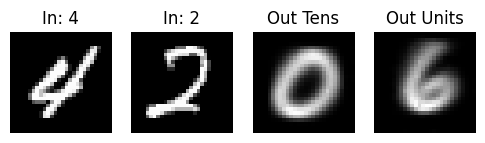

Case: 4 + 3


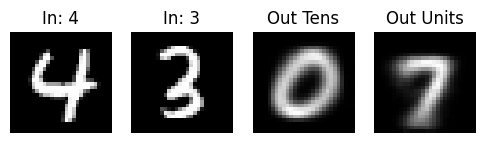

Case: 4 + 4


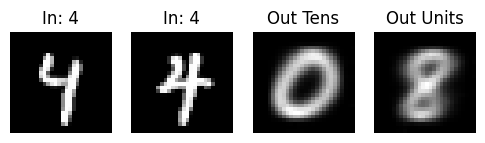

Case: 4 + 5


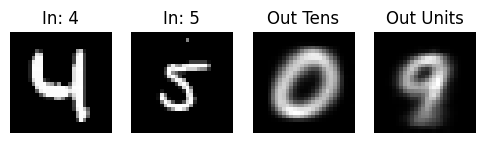

Case: 4 + 6


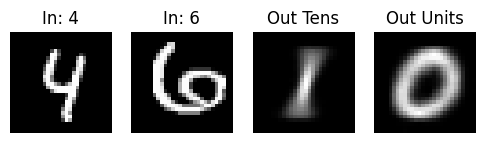

Case: 4 + 7


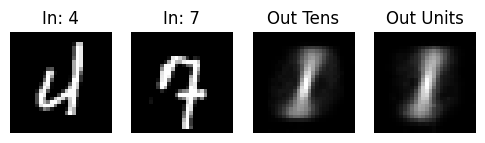

Case: 4 + 8


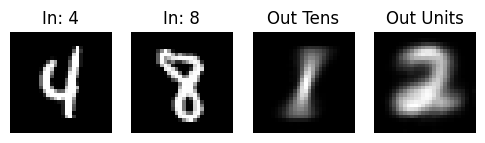

Case: 4 + 9


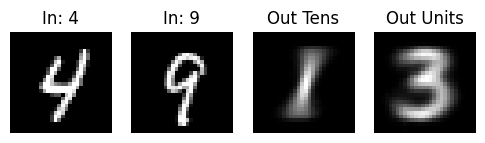

Case: 5 + 0


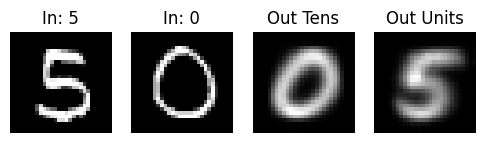

Case: 5 + 1


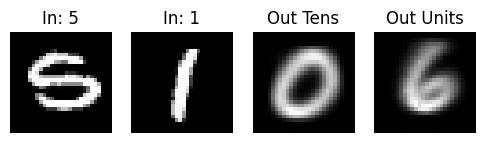

Case: 5 + 2


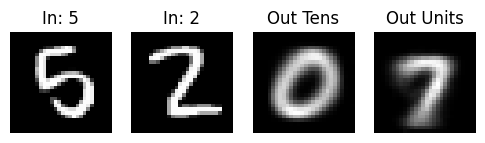

Case: 5 + 3


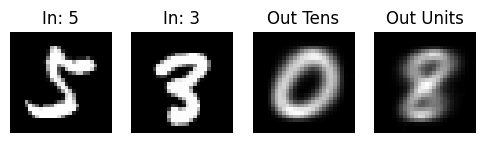

Case: 5 + 4


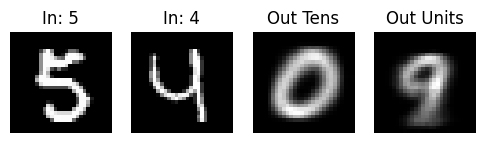

Case: 5 + 5


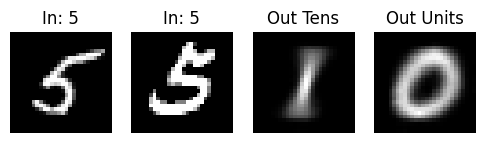

Case: 5 + 6


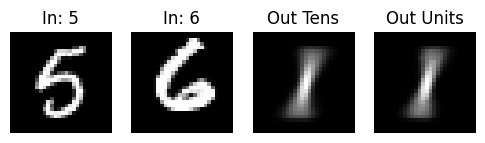

Case: 5 + 7


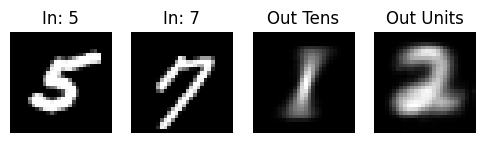

Case: 5 + 8


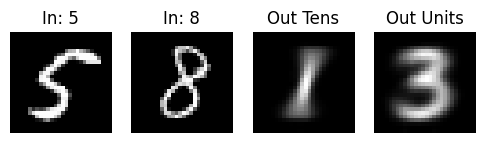

Case: 5 + 9


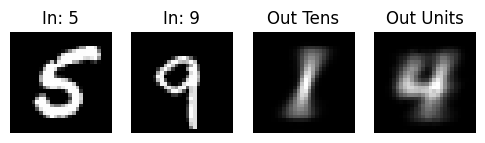

Case: 6 + 0


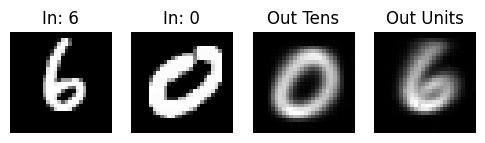

Case: 6 + 1


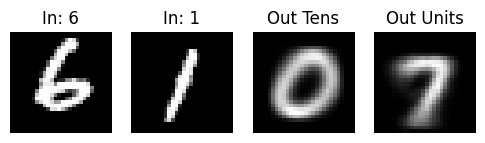

Case: 6 + 2


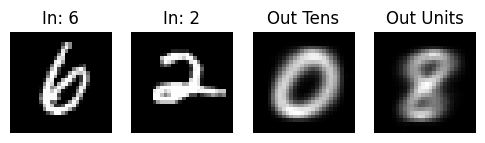

Case: 6 + 3


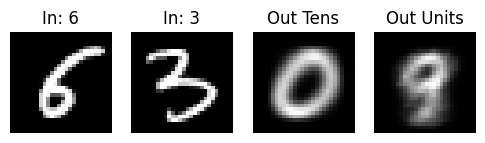

Case: 6 + 4


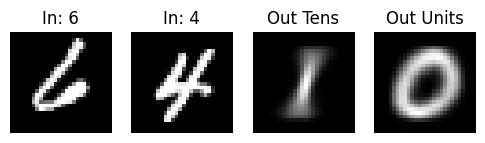

Case: 6 + 5


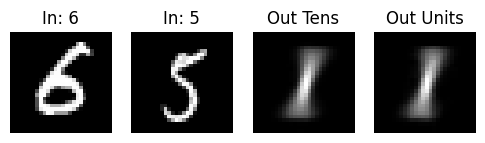

Case: 6 + 6


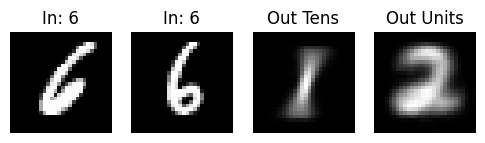

Case: 6 + 7


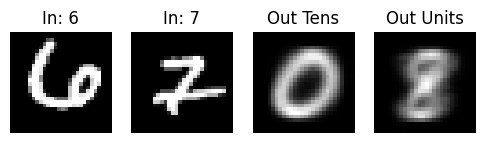

Case: 6 + 8


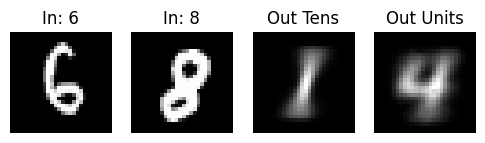

Case: 6 + 9


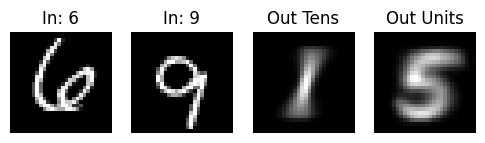

Case: 7 + 0


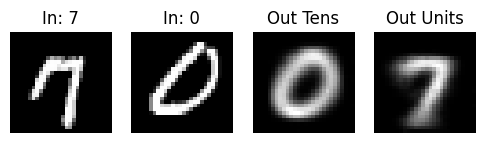

Case: 7 + 1


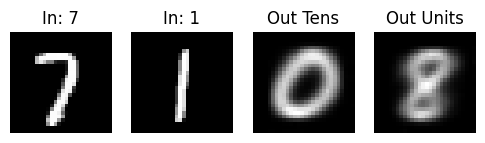

Case: 7 + 2


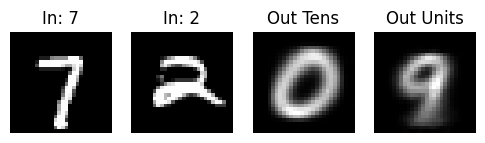

Case: 7 + 3


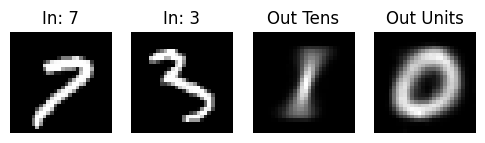

Case: 7 + 4


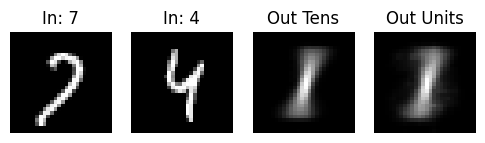

Case: 7 + 5


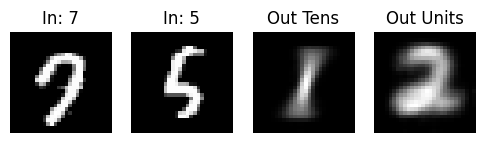

Case: 7 + 6


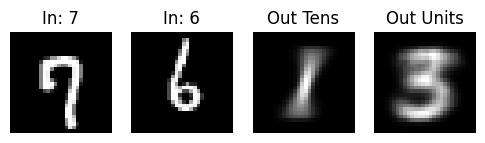

Case: 7 + 7


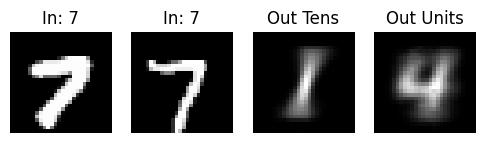

Case: 7 + 8


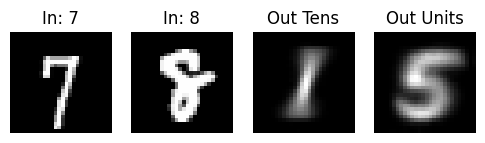

Case: 7 + 9


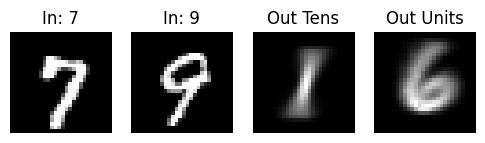

Case: 8 + 0


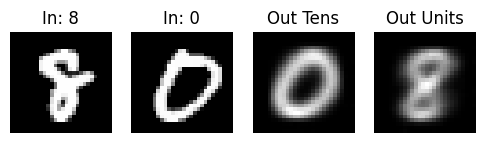

Case: 8 + 1


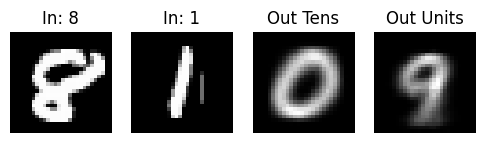

Case: 8 + 2


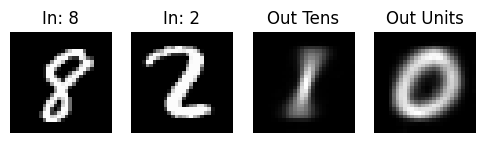

Case: 8 + 3


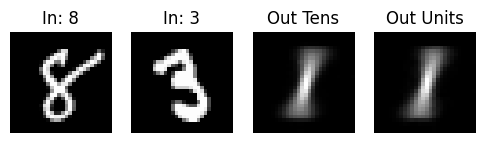

Case: 8 + 4


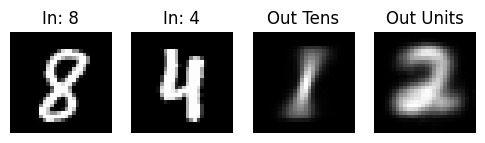

Case: 8 + 5


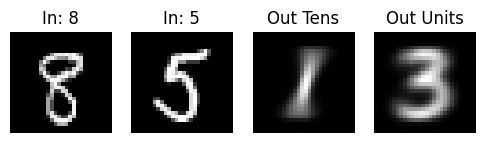

Case: 8 + 6


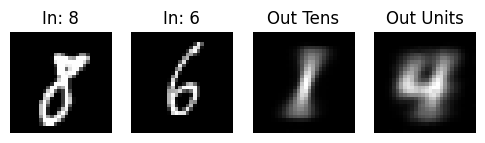

Case: 8 + 7


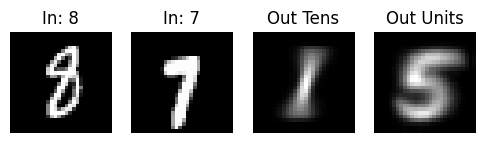

Case: 8 + 8


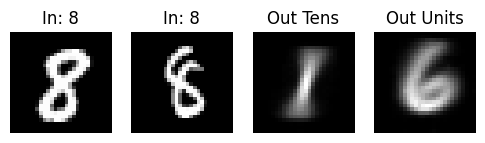

Case: 8 + 9


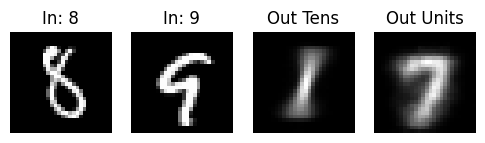

Case: 9 + 0


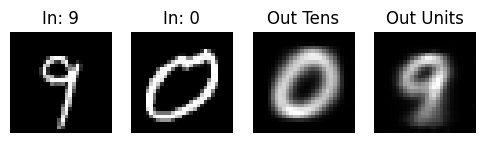

Case: 9 + 1


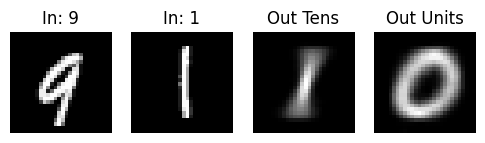

Case: 9 + 2


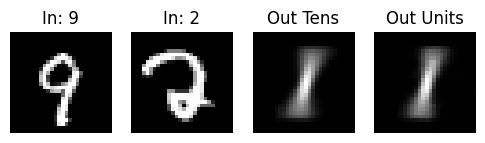

Case: 9 + 3


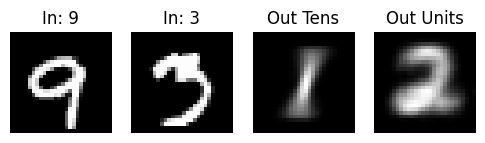

Case: 9 + 4


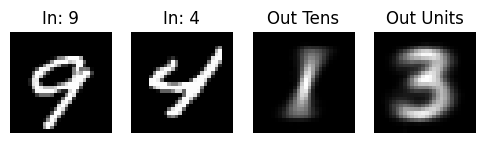

Case: 9 + 5


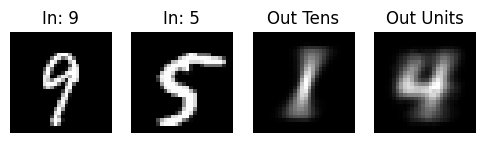

Case: 9 + 6


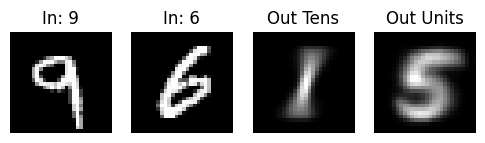

Case: 9 + 7


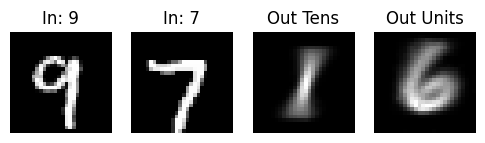

Case: 9 + 8


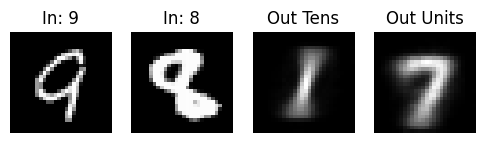

Case: 9 + 9


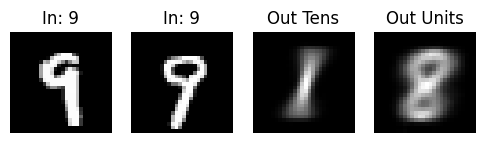

In [120]:
# (Manual Examples)
def manual_adder_examples(n1, n2):
    # Find random images for these numbers
    idx1 = np.random.choice(test_adder_ds.digit_indices[n1])
    idx2 = np.random.choice(test_adder_ds.digit_indices[n2])

    img1 = test_adder_ds.images[idx1].unsqueeze(0).to(DEVICE)
    img2 = test_adder_ds.images[idx2].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        gt, gu = adder_model(img1, img2)

    plt.figure(figsize=(6, 2))
    plots = [img1, img2, gt, gu]
    titles = [f"In: {n1}", f"In: {n2}", "Out Tens", "Out Units"]

    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(plots[i].cpu().squeeze(), cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


print("\n--- All Addition Cases ---")
for n1 in range(10):
    for n2 in range(10):
          print(f"Case: {n1} + {n2}")
          manual_adder_examples(n1, n2)

Visual Adder Accuracy (Judge): 96.64%


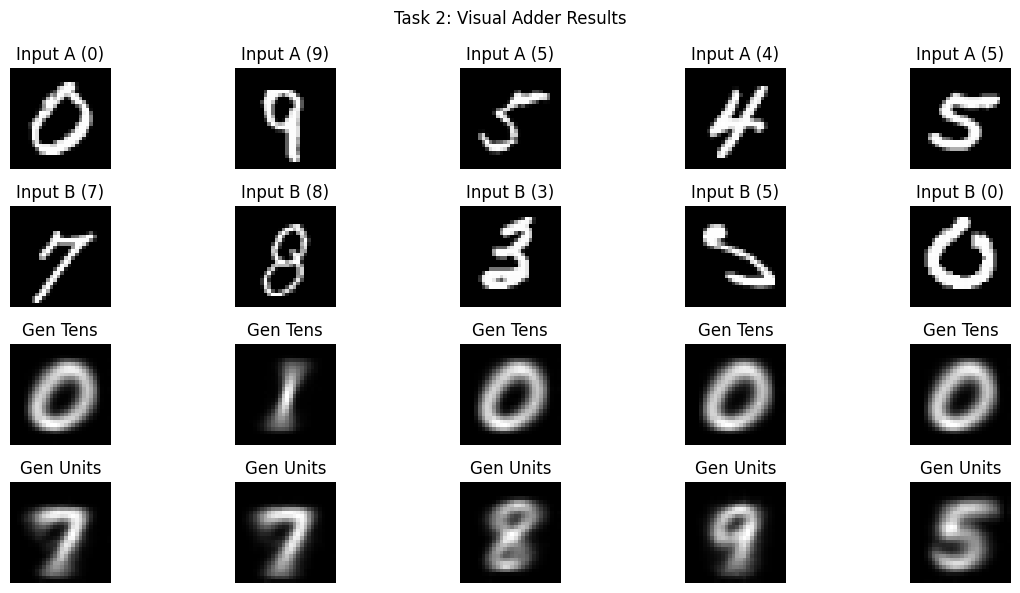

In [99]:
acc_adder, in_viz_add, out_viz_add = evaluate_model(adder_model, 'adder', loaders['adder_test'], judge)
print(f"Visual Adder Accuracy (Judge): {acc_adder*100:.2f}%")
plot_adder(in_viz_add, out_viz_add)

#Confusion Matrices

Generating Confusion Matrix for MSE Model Errors...


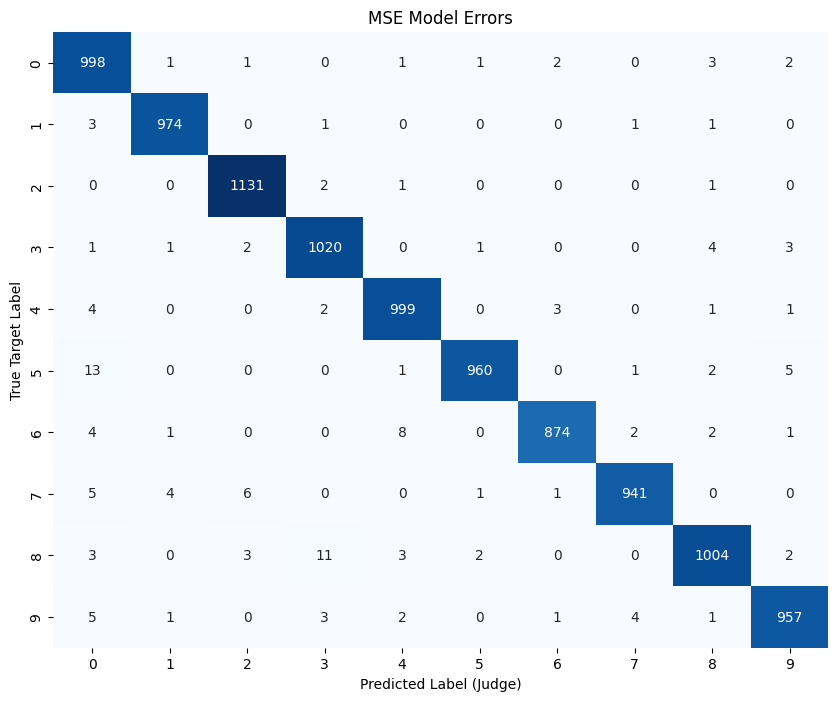

Accuracy per Target Digit:
Target 0: 98.9%
Target 1: 99.4%
Target 2: 99.6%
Target 3: 98.8%
Target 4: 98.9%
Target 5: 97.8%
Target 6: 98.0%
Target 7: 98.2%
Target 8: 97.7%
Target 9: 98.3%


In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(generator_model, loader, judge_model, title="Confusion Matrix", task_type='next_digit'):
    generator_model.eval()
    judge_model.eval()

    if task_type == 'next_digit' or task_type == 'recon':
        y_true = []
        y_pred = []

        print(f"Generating Confusion Matrix for {title}...")

        with torch.no_grad():
            for batch in loader:
                if task_type == 'recon':
                    inp, target_img, original_input_label = batch
                    expected_labels = original_input_label # Directly use the input label as ground truth for recon
                elif task_type == 'next_digit':
                    inp, target_img, original_input_label, next_digit_label = batch
                    expected_labels = next_digit_label # Directly use the next digit label as ground truth

                inp = inp.to(DEVICE)
                expected_labels = expected_labels.to(DEVICE)

                # Generate Image
                fake_imgs = generator_model(inp)

                # Judge the Generated Image
                predicted_logits = judge_model(fake_imgs)
                predicted_labels = torch.argmax(predicted_logits, dim=1).cpu().numpy()

                y_true.extend(expected_labels.cpu().numpy())
                y_pred.extend(predicted_labels)

        # Compute Matrix
        cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))

        # Plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Label (Judge)')
        plt.ylabel('True Target Label')
        plt.title(title)
        plt.show()

        # Calculate accuracy per class
        class_acc = cm.diagonal() / cm.sum(axis=1)
        print("Accuracy per Target Digit:")
        for digit, acc in enumerate(class_acc):
            print(f"Target {digit}: {acc*100:.1f}%")

    elif task_type == 'adder':
        y_true_tens = []
        y_pred_tens = []
        y_true_units = []
        y_pred_units = []

        print(f"Generating Confusion Matrices for {title}...")

        with torch.no_grad():
            for img1, img2, _, _, lbl_tens, lbl_units, _, _ in loader:
                img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
                lbl_tens, lbl_units = lbl_tens.to(DEVICE), lbl_units.to(DEVICE)

                gen_tens, gen_units = generator_model(img1, img2)

                pred_tens_logits = judge_model(gen_tens)
                pred_units_logits = judge_model(gen_units)

                pred_tens = torch.argmax(pred_tens_logits, dim=1).cpu().numpy()
                pred_units = torch.argmax(pred_units_logits, dim=1).cpu().numpy()

                y_true_tens.extend(lbl_tens.cpu().numpy())
                y_pred_tens.extend(pred_tens)
                y_true_units.extend(lbl_units.cpu().numpy())
                y_pred_units.extend(pred_units)

        # Confusion Matrix for Tens Digit
        cm_tens = confusion_matrix(y_true_tens, y_pred_tens, labels=list(range(2))) #Range is 2 because the max sum we can get is 9+9=18 and the tens digit is always either 0 or 1
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_tens, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Tens Label (Judge)')
        plt.ylabel('True Tens Label')
        plt.title(f"{title} - Tens Digit")
        plt.show()

        class_acc_tens = cm_tens.diagonal() / cm_tens.sum(axis=1)
        print("Accuracy per True Tens Digit:")
        for digit, acc in enumerate(class_acc_tens):
            print(f"Tens {digit}: {acc*100:.1f}%")

        # Confusion Matrix for Units Digit
        cm_units = confusion_matrix(y_true_units, y_pred_units, labels=list(range(10)))
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_units, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Units Label (Judge)')
        plt.ylabel('True Units Label')
        plt.title(f"{title} - Units Digit")
        plt.show()

        class_acc_units = cm_units.diagonal() / cm_units.sum(axis=1)
        print("Accuracy per True Units Digit:")
        for digit, acc in enumerate(class_acc_units):
            print(f"Units {digit}: {acc*100:.1f}%")

    else:
        raise ValueError(f"Unknown task type: {task_type}")

# --- Run Analysis ---

# 1. Compare the standard MSE Model (from previous cells)
# Assuming 'model_next' in locals() from the previous run
if 'model_next' in locals():
    plot_confusion_matrix(model_next, DataLoader(test_next_ds, batch_size=256), judge, title="MSE Model Errors", task_type='next_digit')


Generating Confusion Matrix for Recon Model Errors...


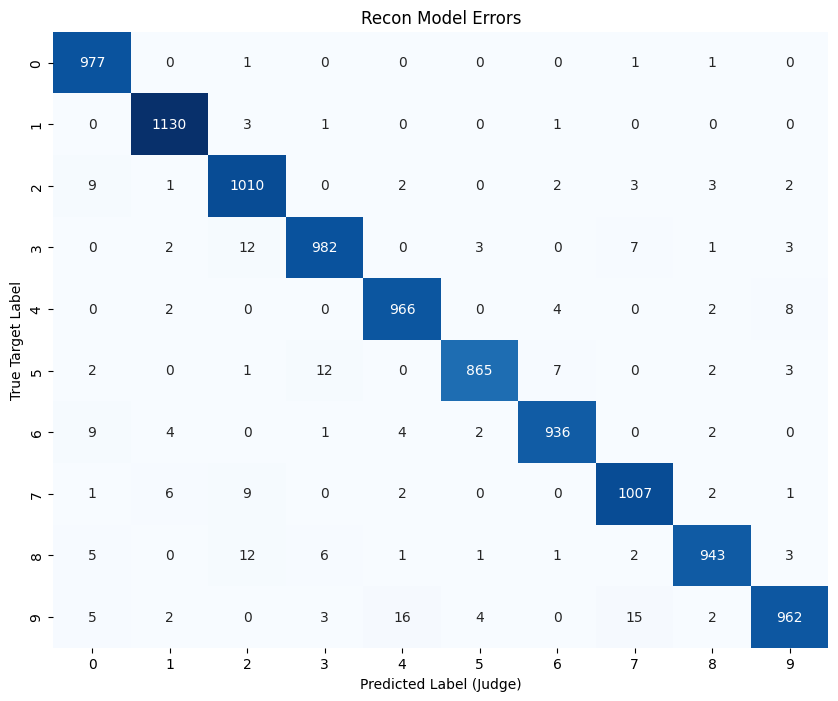

Accuracy per Target Digit:
Target 0: 99.7%
Target 1: 99.6%
Target 2: 97.9%
Target 3: 97.2%
Target 4: 98.4%
Target 5: 97.0%
Target 6: 97.7%
Target 7: 98.0%
Target 8: 96.8%
Target 9: 95.3%


In [115]:
plot_confusion_matrix(model_recon, DataLoader(test_recon_ds, batch_size=256), judge, title="Recon Model Errors", task_type='recon')
#

Generating Confusion Matrix for Next Digit Model Errors...


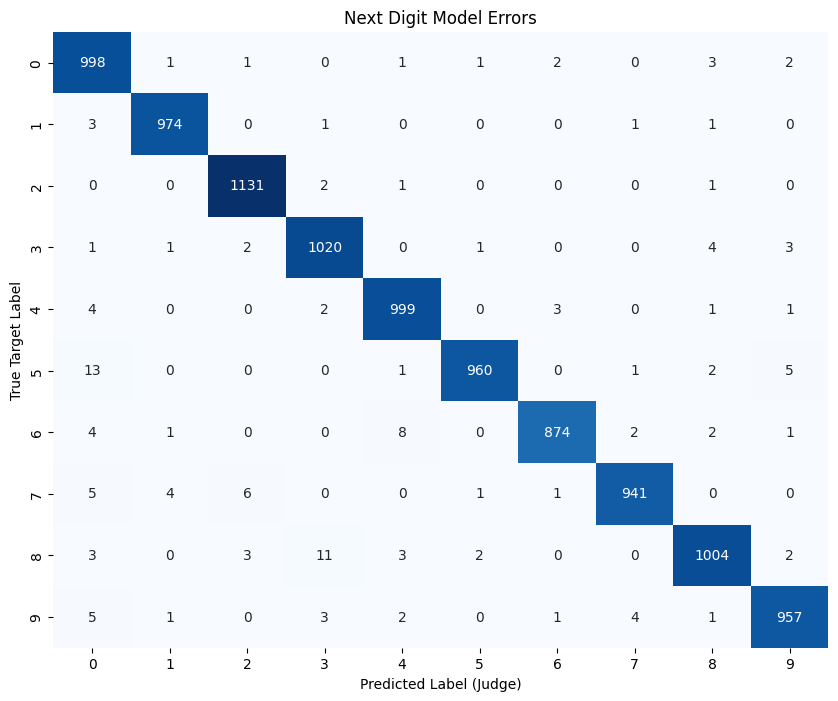

Accuracy per Target Digit:
Target 0: 98.9%
Target 1: 99.4%
Target 2: 99.6%
Target 3: 98.8%
Target 4: 98.9%
Target 5: 97.8%
Target 6: 98.0%
Target 7: 98.2%
Target 8: 97.7%
Target 9: 98.3%


In [118]:
plot_confusion_matrix(best_model_next, DataLoader(test_next_ds, batch_size=256), judge, title="Next Digit Model Errors", task_type='next_digit')
#

Generating Confusion Matrices for Adder Model Errors...


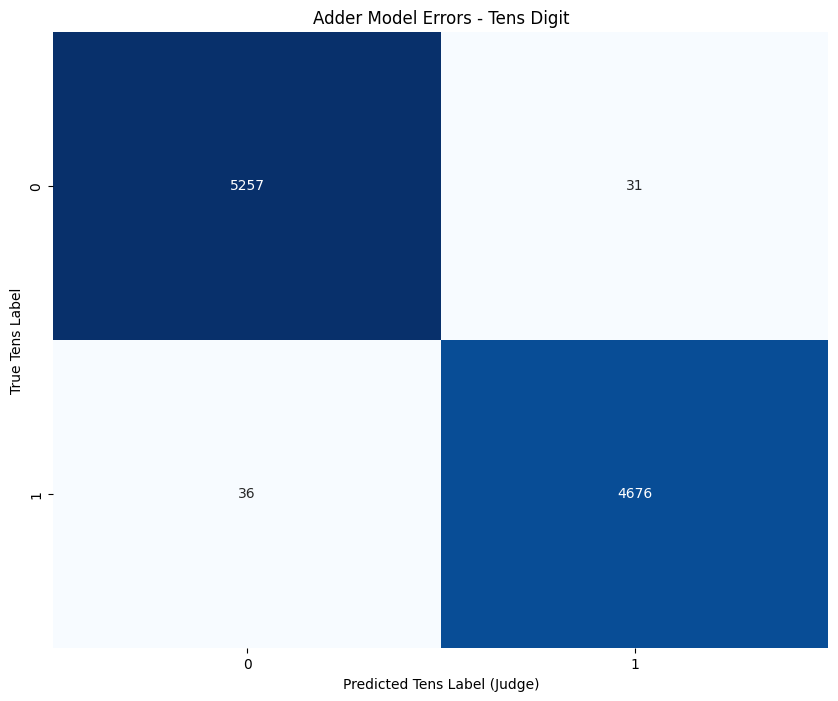

Accuracy per True Tens Digit:
Tens 0: 99.4%
Tens 1: 99.2%


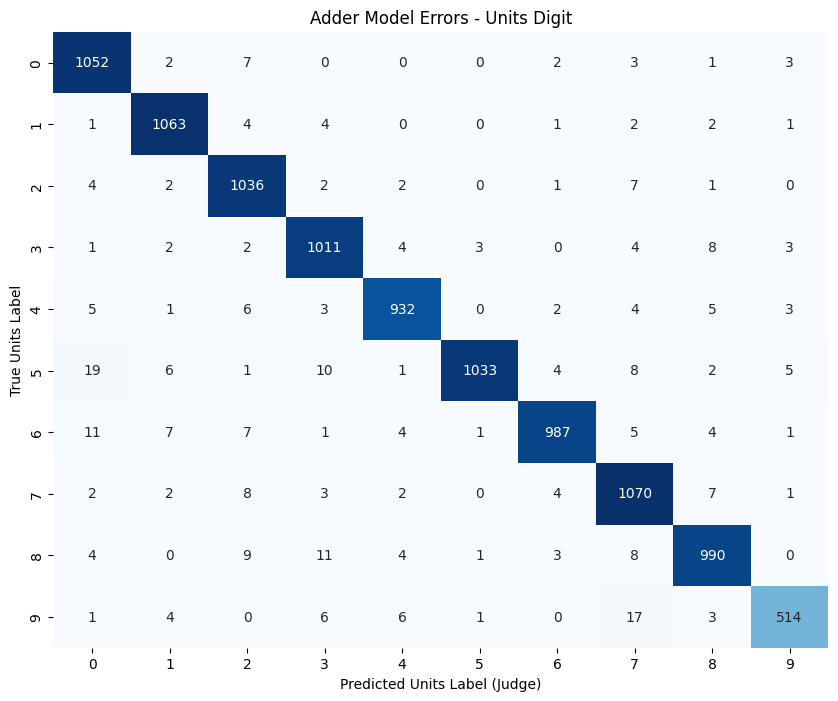

Accuracy per True Units Digit:
Units 0: 98.3%
Units 1: 98.6%
Units 2: 98.2%
Units 3: 97.4%
Units 4: 97.0%
Units 5: 94.9%
Units 6: 96.0%
Units 7: 97.4%
Units 8: 96.1%
Units 9: 93.1%


In [119]:
plot_confusion_matrix(adder_model, DataLoader(test_adder_ds, batch_size=256), judge, title="Adder Model Errors", task_type='adder')
